<a href="https://colab.research.google.com/github/N17-R4M/bigdata-lab-FFLM/blob/main/Ultima%20Atualizacao_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install "numpy<2" scikit-learn-extra

In [3]:
# ==========================================
# INGESTÃO DE DADOS (CAMADA BRONZE) E VISUALIZAÇÃO INICIAL
# ==========================================
# 1. Importação das bibliotecas essenciais para o pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Configuração visual padrão para os gráficos do projeto
sns.set_theme(style="whitegrid", palette="muted")

# 2. Conexão com o repositório de dados (Google Drive)
drive.mount('/content/drive')
caminho_drive = '/content/drive/MyDrive/Projeto_ENEM/'


# 3. Leitura dos microdados
# Justificativa técnica:
# - sep=';' e encoding='latin1' são o padrão dos sistemas do INEP.
# - low_memory=False garante a leitura integral e evita erros de inferência de tipagem em bases massivas.
df_participantes = pd.read_csv(caminho_drive + 'PARTICIPANTES_2024.csv', sep=';', encoding='latin1', low_memory=False)
df_resultados = pd.read_csv(caminho_drive + 'RESULTADOS_2024.csv', sep=';', encoding='latin1', low_memory=False)

# 4. Validação da Ingestão (Sanity Check)
print(f"Base de Participantes carregada: {df_participantes.shape[0]} linhas e {df_participantes.shape[1]} colunas.")
print(f"Base de Resultados carregada: {df_resultados.shape[0]} linhas e {df_resultados.shape[1]} colunas.\n")

# Listagem do Schema (Colunas disponíveis)
print("Colunas da base Participantes:", df_participantes.columns.tolist())
print("\nColunas da base Resultados:", df_resultados.columns.tolist())

# 5. Inspeção Visual dos Dados
# Força o Pandas a renderizar TODAS as colunas, impedindo a ocultação com "..."
pd.set_option('display.max_columns', None)

print("\nVISUALIZAÇÃO: BASE DE PARTICIPANTES (Amostra das Primeiras e Últimas 5 linhas)")
# O concat de head() e tail() permite auditar o início e o fim da ingestão de uma só vez
display(pd.concat([df_participantes.head(), df_participantes.tail()]))

print("\n" + "="*80 + "\n")

print("VISUALIZAÇÃO: BASE DE RESULTADOS (Amostra das Primeiras e Últimas 5 linhas)")
display(pd.concat([df_resultados.head(), df_resultados.tail()]))

# Opcional recomendado: Resetar a configuração para o padrão do Pandas para não poluir saídas futuras
pd.reset_option('display.max_columns')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base de Participantes carregada: 4332944 linhas e 38 colunas.
Base de Resultados carregada: 4332944 linhas e 42 colunas.

Colunas da base Participantes: ['NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ENSINO', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023']

Colunas da base Resultados: ['NU_SEQUENCIAL', 'NU_ANO', 'CO_ESCOLA', 'CO_MUNICIPIO_ESC', 'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA', 'TP_P

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023
0,210062064233,2024,5,F,1,1,1,1,3,NaN,0,4314902,Porto Alegre,43,RS,F,F,C,D,4,B,C,A,C,D,C,B,B,A,B,B,B,D,A,B,B,E,A
1,210062064234,2024,11,F,1,1,1,1,10,NaN,0,4318903,São Luiz Gonzaga,43,RS,B,C,A,D,2,B,E,A,B,B,B,B,B,A,A,A,A,B,A,B,A,C,A
2,210062064235,2024,11,F,1,1,1,1,9,NaN,0,4320107,Sarandi,43,RS,H,F,F,D,5,B,J,A,C,D,B,B,C,A,B,B,B,D,B,B,A,D,A
3,210062064236,2024,3,F,1,3,1,2,0,1.0,0,4313409,Novo Hamburgo,43,RS,B,B,B,B,6,A,C,A,B,C,B,A,B,A,B,A,A,A,A,B,A,D,A
4,210062064237,2024,16,M,3,1,1,1,18,NaN,0,4309209,Gravataí,43,RS,B,B,C,C,2,A,A,A,B,C,A,A,B,A,A,A,A,B,A,B,A,B,A
4332939,210066495575,2024,7,M,1,1,1,1,2,NaN,0,4314407,Pelotas,43,RS,A,B,F,B,4,A,C,A,C,B,A,A,B,A,B,A,A,B,A,B,A,C,A
4332940,210066495576,2024,6,M,1,3,1,3,0,NaN,1,4314407,Pelotas,43,RS,B,C,B,F,3,B,C,A,B,C,B,B,B,A,A,A,A,C,A,B,A,C,A
4332941,210066495577,2024,4,F,1,2,1,1,1,NaN,0,3518800,Guarulhos,35,SP,E,E,C,D,5,A,E,A,B,C,B,A,B,A,B,B,A,B,A,B,B,B,A
4332942,210066495578,2024,2,F,1,3,1,2,0,NaN,0,2930105,Senhor do Bonfim,29,BA,C,C,A,B,7,A,B,A,B,D,A,A,A,A,A,A,A,B,A,A,A,B,A
4332943,210066495579,2024,1,F,1,1,1,3,0,NaN,1,3555406,Ubatuba,35,SP,H,E,D,D,3,A,F,B,B,C,B,B,B,B,B,A,A,B,B,B,A,D,D




VISUALIZAÇÃO: BASE DE RESULTADOS (Amostra das Primeiras e Últimas 5 linhas)


,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,2111508,São Mateus do Maranhão,21,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4332939,1966623,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5300108,Brasília,53,DF,1,1,1,1,1420.0,1383.0,1395.0,1408.0,564.1,649.5,619.8,609.9,EAEBAECEEBEBDEBCBDCAAAEBCCDDBDEEBEBBDDABABDBA,CEDBBEBEDADDDEEBABCDCAECEDABBEEAEEADCEDADACDE,CCDDDECBECCDDBBDEBDCECBCCBDAADCBDBDDABEDACEEB,CECDDBDBAAEDBEADDBCBAEBCAEDCBDACCBBDADCADCBAD,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,120.0,120.0,120.0,140.0,140.0,640.0
4332940,1661560,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1702109,Araguaína,17,TO,1,1,1,1,1420.0,1383.0,1395.0,1408.0,455.2,436.2,440.2,503.2,ACCBCECEEBDBEEEAEBDCDACABADAECAECCEBBCDCDDDEB,AACABCACCDCADDEEAABDDABCDBAEEEDCAAACEDBABEDDA,CBBDCEEBEAEDEADAEBDAAAEADADBDCAADADADADBAECDC,EA*BABCEDBBCCBBCBCCBDCDAACECBEEBEABEBCBAAABED,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDED

Linhas com ruído no questionário removidas.

Análise de Valores Nulos PÓS-LIMPEZA:
--------------------------------------------------
>>> NULOS EM PARTICIPANTES (Deverá ser 0 para as questões) <<<


,0
CO_MUNICIPIO_PROVA,0
NO_MUNICIPIO_PROVA,0
Q022,0
Q021,0
Q020,0



>>> NULOS EM RESULTADOS <<<
(Nota: Nulos em NU_NOTA_... são esperados e representam os candidatos que FALTARAM à prova)


,0
NU_NOTA_MT,1327963
NU_NOTA_CN,1327963
NU_NOTA_LC,1164989
NU_NOTA_COMP5,1164989
NU_NOTA_COMP4,1164989


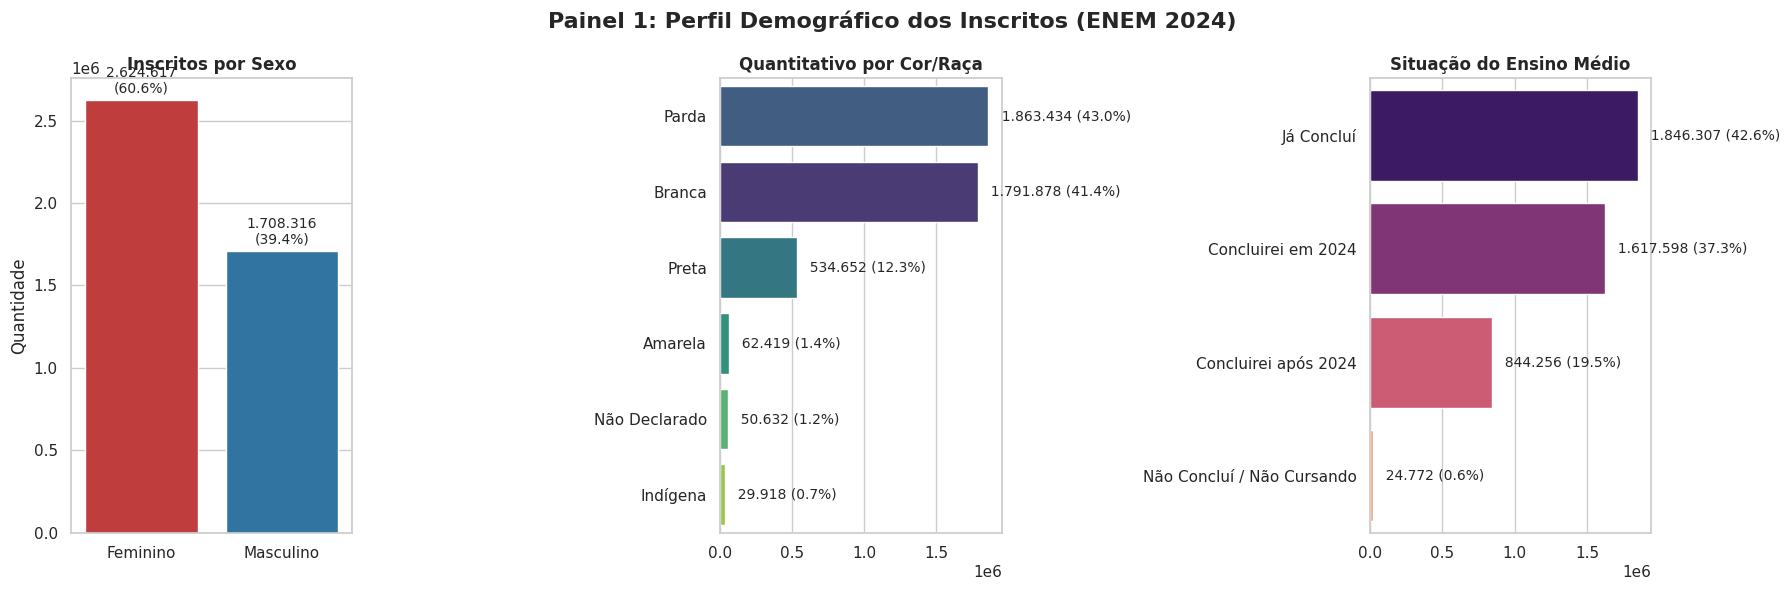

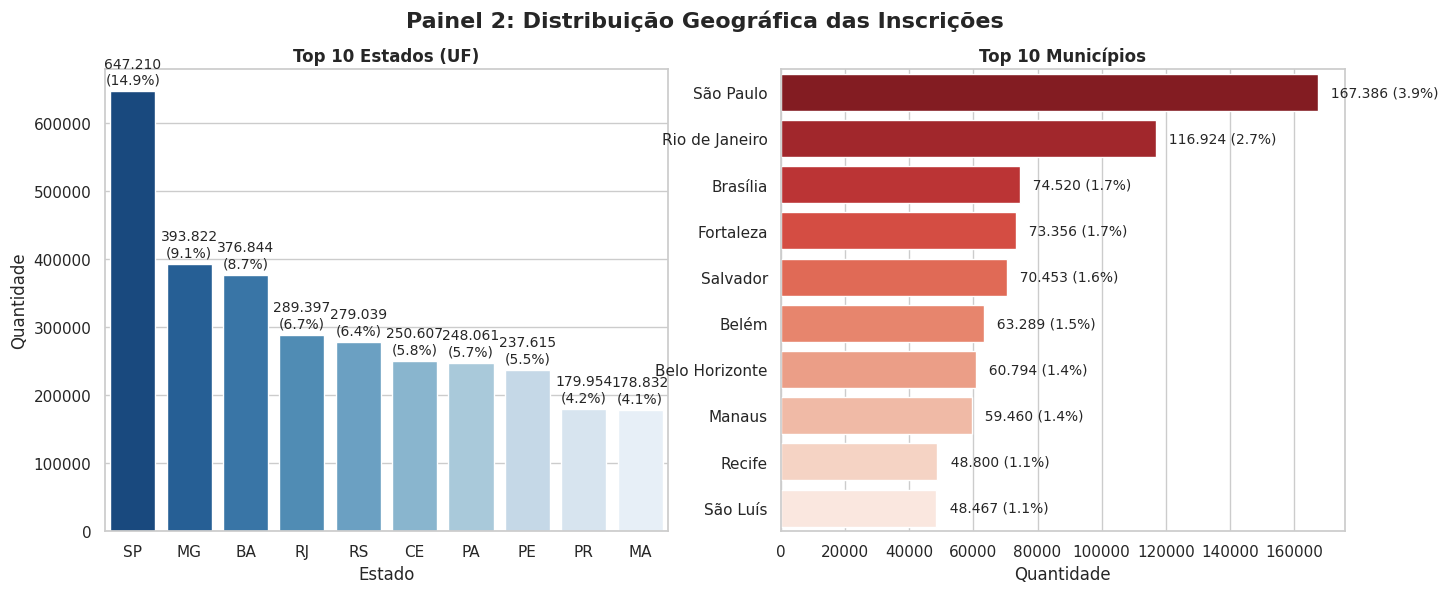

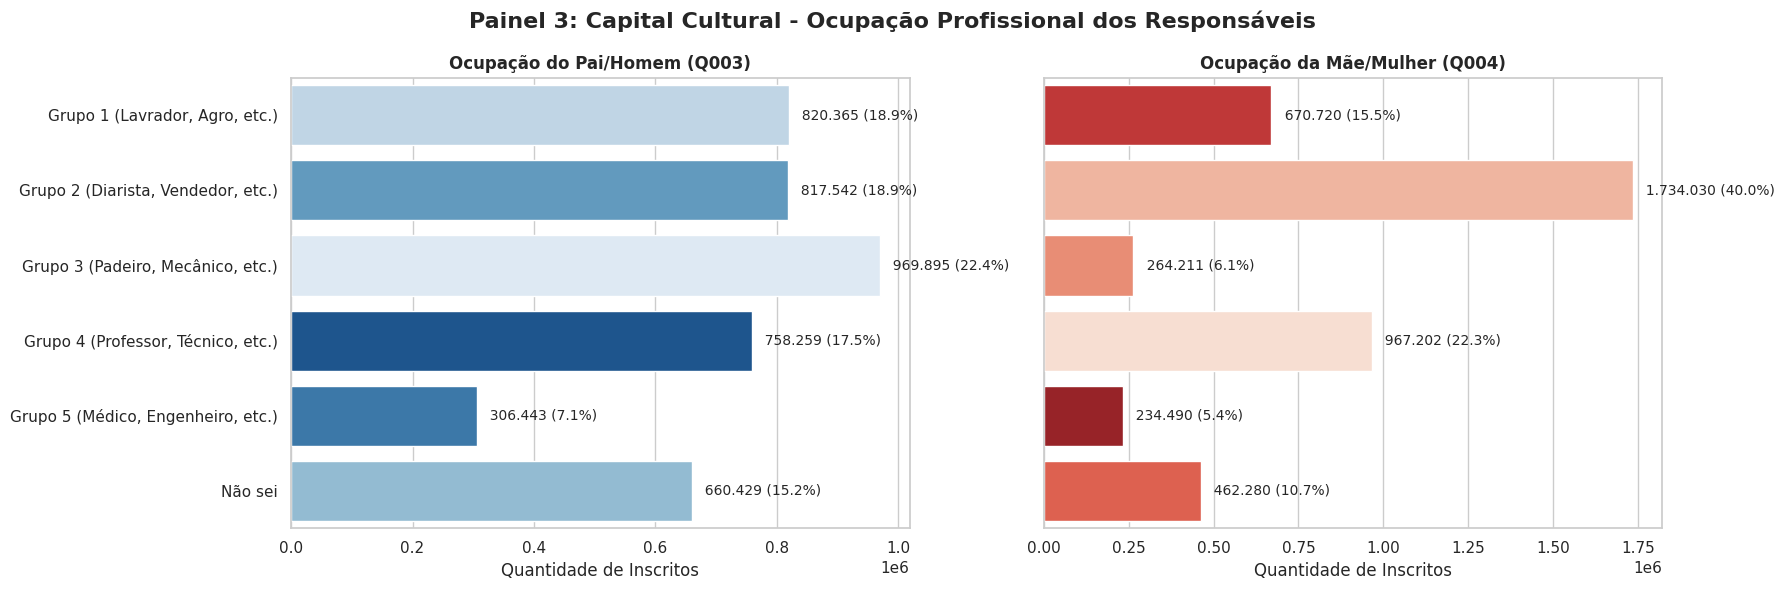

In [4]:
# 1. Escopo de Participantes
colunas_part_oficial = [
    'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'CO_UF_PROVA', 'SG_UF_PROVA',
    'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_COR_RACA', 'TP_ST_CONCLUSAO',
    'Q001', 'Q002', 'Q003','Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010',
    'Q011', 'Q012', 'Q013', 'Q015', 'Q016', 'Q018', 'Q020', 'Q021',
    'Q022', 'Q023'
]

# 2. Escopo de Resultados
# - Removemos todas as colunas _ESC (Escola) que geravam 2.7M de nulos.
# - Devolvemos TP_PRESENCA_MT para ser o nosso "marcador oficial" de abstenção.
colunas_res_oficial = [
    'NU_SEQUENCIAL', 'NU_ANO', 'CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA',
    'CO_UF_PROVA','SG_UF_PROVA', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH',
    'NU_NOTA_LC', 'NU_NOTA_MT', 'TP_STATUS_REDACAO', 'NU_NOTA_COMP1',
    'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4', 'NU_NOTA_COMP5', 'NU_NOTA_REDACAO'
]

# 3. Alocação de Memória (Criando os DataFrames enxutos)
df_part_limpo = df_participantes[colunas_part_oficial].copy()
df_res_limpo = df_resultados[colunas_res_oficial].copy()

# Deletamos os DataFrames originais gigantes para salvar a RAM do Colab
del df_participantes
del df_resultados


# 4. TRATAMENTO DE NULOS
df_part_limpo.dropna(subset=['Q001', 'Q006', 'Q008', 'Q009', 'Q016'], inplace=True)
print("Linhas com ruído no questionário removidas.\n")

# 5. Diagnóstico Final de Nulos
print("Análise de Valores Nulos PÓS-LIMPEZA:")
print("-" * 50)
print(">>> NULOS EM PARTICIPANTES (Deverá ser 0 para as questões) <<<")
display(df_part_limpo.isnull().sum().sort_values(ascending=False).head(5))

print("\n>>> NULOS EM RESULTADOS <<<")
print("(Nota: Nulos em NU_NOTA_... são esperados e representam os candidatos que FALTARAM à prova)")
display(df_res_limpo.isnull().sum().sort_values(ascending=False).head(5))

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
total_alunos = len(df_part_limpo)

# 1. Número absoluto + Porcentagem (%)
def adicionar_valores_br(ax, total, orientacao='v'):
    for container in ax.containers:
        if orientacao == 'v':
            # Gráficos verticais
            ax.bar_label(container,
                         fmt=lambda x: f"{int(x):,}".replace(",", ".") + f"\n({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)
        else:
            # Gráficos horizontais
            ax.bar_label(container,
                         fmt=lambda x: f"  {int(x):,}".replace(",", ".") + f" ({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)

# 2. Mapeamentos e Traduções para visualização
df_part_limpo['DESC_SEXO'] = df_part_limpo['TP_SEXO'].map({'M': 'Masculino', 'F': 'Feminino'})

mapa_raca = {0: 'Não Declarado', 1: 'Branca', 2: 'Preta', 3: 'Parda', 4: 'Amarela', 5: 'Indígena', 6: 'Sem Info'}
df_part_limpo['DESC_RACA'] = df_part_limpo['TP_COR_RACA'].map(mapa_raca)

mapa_conclusao = {1: 'Já Concluí', 2: 'Concluirei em 2024', 3: 'Concluirei após 2024', 4: 'Não Concluí / Não Cursando'}
df_part_limpo['DESC_CONCLUSAO'] = df_part_limpo['TP_ST_CONCLUSAO'].map(mapa_conclusao)

# Mapeamento para as colunas Q003 e Q004, referentes à ocupação profissional dos responsáveis
mapa_ocupacao = {
    'A': 'Grupo 1 (Lavrador, Agro, etc.)',
    'B': 'Grupo 2 (Diarista, Vendedor, etc.)',
    'C': 'Grupo 3 (Padeiro, Mecânico, etc.)',
    'D': 'Grupo 4 (Professor, Técnico, etc.)',
    'E': 'Grupo 5 (Médico, Engenheiro, etc.)',
    'F': 'Não sei'
}
df_part_limpo['DESC_Q003'] = df_part_limpo['Q003'].map(mapa_ocupacao)
df_part_limpo['DESC_Q004'] = df_part_limpo['Q004'].map(mapa_ocupacao)

# ---------------------------------------------------------
# PAINEL 1: Identidade e Escolaridade
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Painel 1: Perfil Demográfico dos Inscritos (ENEM 2024)', fontsize=16, fontweight='bold')

# A) Sexo (Cores Específicas)
paleta_sexo = {'Feminino': '#d62728', 'Masculino': '#1f77b4'} # Vermelho e Azul
sns.countplot(data=df_part_limpo, x='DESC_SEXO', hue='DESC_SEXO', palette=paleta_sexo, ax=axes[0], legend=False)
axes[0].set_title('Inscritos por Sexo', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Quantidade')
adicionar_valores_br(axes[0], total_alunos, orientacao='v')

# B) Cor/Raça
sns.countplot(data=df_part_limpo, y='DESC_RACA', hue='DESC_RACA', order=df_part_limpo['DESC_RACA'].value_counts().index, palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Quantitativo por Cor/Raça', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
adicionar_valores_br(axes[1], total_alunos, orientacao='h')

# C) Situação do Ensino Médio
sns.countplot(data=df_part_limpo, y='DESC_CONCLUSAO', hue='DESC_CONCLUSAO', order=df_part_limpo['DESC_CONCLUSAO'].value_counts().index, palette='magma', ax=axes[2], legend=False)
axes[2].set_title('Situação do Ensino Médio', fontweight='bold')
axes[2].set_xlabel(''); axes[2].set_ylabel('')
adicionar_valores_br(axes[2], total_alunos, orientacao='h')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 2: Geografia e Distribuição
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('Painel 2: Distribuição Geográfica das Inscrições', fontsize=16, fontweight='bold')

# A) Top 10 Estados
top_ufs = df_part_limpo['SG_UF_PROVA'].value_counts().head(10)
sns.barplot(x=top_ufs.index, y=top_ufs.values, hue=top_ufs.index, palette='Blues_r', ax=axes2[0], legend=False)
axes2[0].set_title('Top 10 Estados (UF)', fontweight='bold')
axes2[0].set_xlabel('Estado'); axes2[0].set_ylabel('Quantidade')
# Para pegar a base do Total Nacional e não dar mais de 100%, passamos o total_alunos
adicionar_valores_br(axes2[0], total_alunos, orientacao='v')

# B) Top 10 Municípios
top_cidades = df_part_limpo['NO_MUNICIPIO_PROVA'].value_counts().head(10)
sns.barplot(y=top_cidades.index, x=top_cidades.values, hue=top_cidades.index, palette='Reds_r', ax=axes2[1], legend=False)
axes2[1].set_title('Top 10 Municípios', fontweight='bold')
axes2[1].set_xlabel('Quantidade'); axes2[1].set_ylabel('')
adicionar_valores_br(axes2[1], total_alunos, orientacao='h')

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig3.suptitle('Painel 3: Capital Cultural - Ocupação Profissional dos Responsáveis', fontsize=16, fontweight='bold')

# Ordem lógica do Dicionário (A ao F)
ordem_ocupacao = [
    'Grupo 1 (Lavrador, Agro, etc.)', 'Grupo 2 (Diarista, Vendedor, etc.)',
    'Grupo 3 (Padeiro, Mecânico, etc.)', 'Grupo 4 (Professor, Técnico, etc.)',
    'Grupo 5 (Médico, Engenheiro, etc.)', 'Não sei'
]

# A) Profissão do Pai (Azul)
sns.countplot(data=df_part_limpo, y='DESC_Q003', hue='DESC_Q003', order=ordem_ocupacao, palette='Blues', ax=axes3[0], legend=False)
axes3[0].set_title('Ocupação do Pai/Homem (Q003)', fontweight='bold')
axes3[0].set_xlabel('Quantidade de Inscritos'); axes3[0].set_ylabel('')
adicionar_valores_br(axes3[0], total_alunos, orientacao='h')

# B) Profissão da Mãe (Vermelho)
sns.countplot(data=df_part_limpo, y='DESC_Q004', hue='DESC_Q004', order=ordem_ocupacao, palette='Reds', ax=axes3[1], legend=False)
axes3[1].set_title('Ocupação da Mãe/Mulher (Q004)', fontweight='bold')
axes3[1].set_xlabel('Quantidade de Inscritos'); axes3[1].set_ylabel('')
adicionar_valores_br(axes3[1], total_alunos, orientacao='h')

plt.tight_layout()
plt.show()


Iniciando Análise Socioeconômica (Q001 a Q008)...



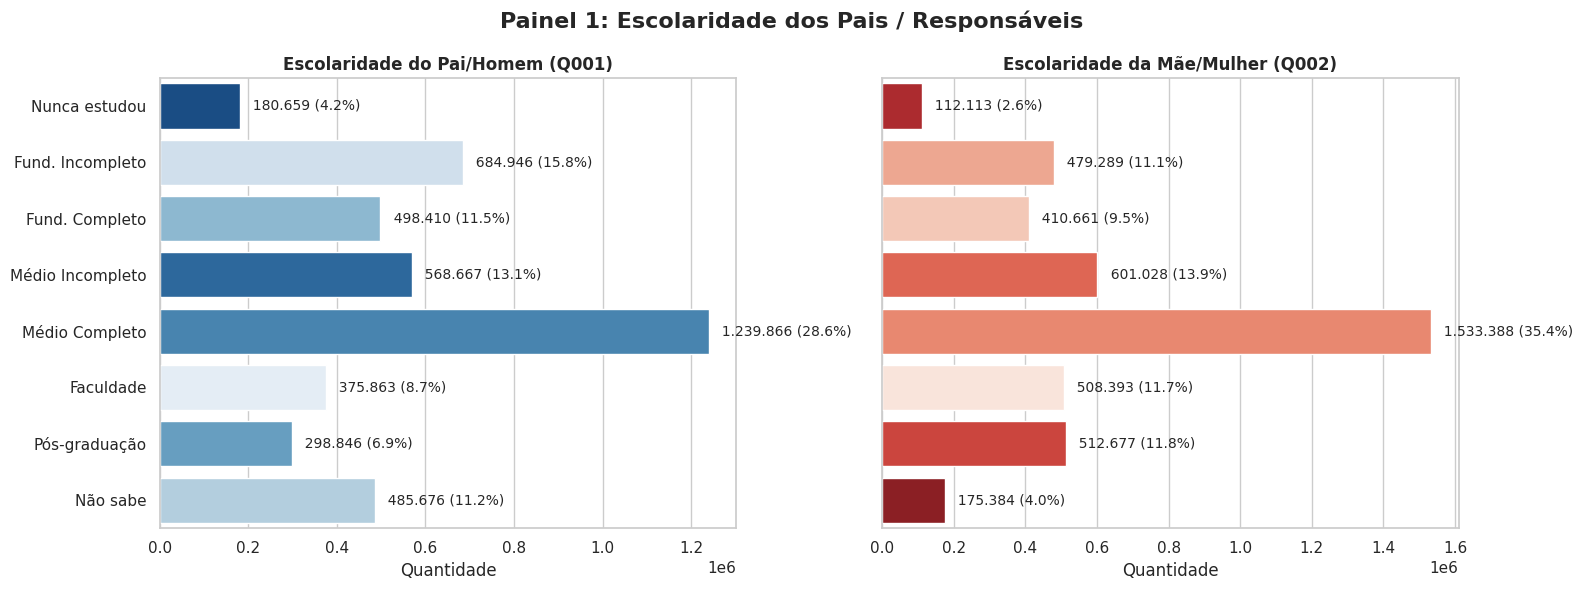

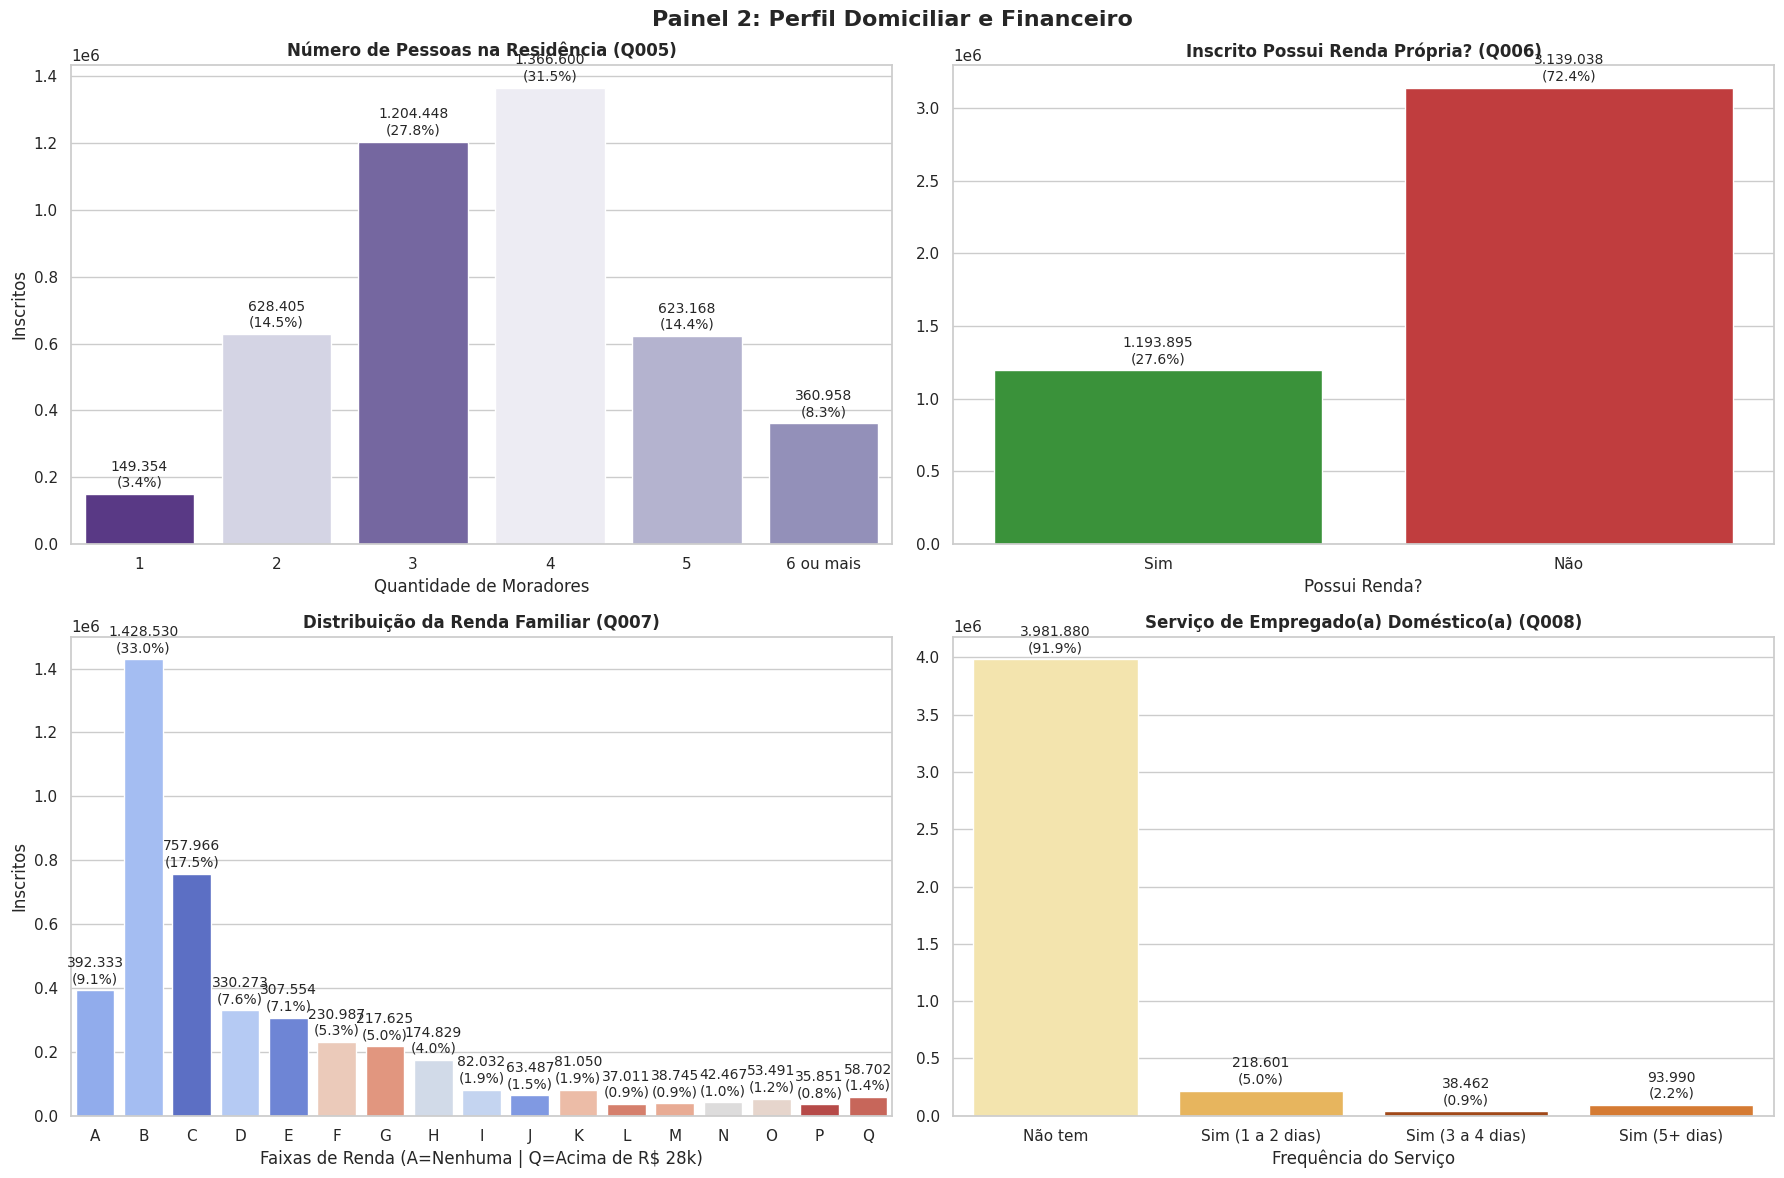

In [5]:
# ==========================================
# ANÁLISE SOCIOECONÔMICA (Dashboards Q001 a Q008)
# ==========================================
print("Iniciando Análise Socioeconômica (Q001 a Q008)...\n")

sns.set_theme(style="whitegrid")
total_alunos = len(df_part_limpo)

# 1. Número Absoluto com formatação BR + Porcentagem
def adicionar_valores_br(ax, total, orientacao='v'):
    for container in ax.containers:
        if orientacao == 'v':
            # Gráficos verticais
            ax.bar_label(container,
                         fmt=lambda x: f"{int(x):,}".replace(",", ".") + f"\n({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)
        else:
            # Gráficos horizontais
            ax.bar_label(container,
                         fmt=lambda x: f"  {int(x):,}".replace(",", ".") + f" ({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)

# 2. Mapeamentos
mapa_escolaridade = {
    'A': 'Nunca estudou', 'B': 'Fund. Incompleto', 'C': 'Fund. Completo',
    'D': 'Médio Incompleto', 'E': 'Médio Completo', 'F': 'Faculdade',
    'G': 'Pós-graduação', 'H': 'Não sabe'
}

df_part_limpo['DESC_Q001'] = df_part_limpo['Q001'].map(mapa_escolaridade)
df_part_limpo['DESC_Q002'] = df_part_limpo['Q002'].map(mapa_escolaridade)

# Agrupamento moradores
df_part_limpo['Q005_GRUPO'] = df_part_limpo['Q005'].apply(lambda x: str(x) if x < 6 else '6 ou mais')

df_part_limpo['DESC_Q006'] = df_part_limpo['Q006'].map({'A': 'Não', 'B': 'Sim'})

mapa_domestico = {
    'A': 'Não tem', 'B': 'Sim (1 a 2 dias)',
    'C': 'Sim (3 a 4 dias)', 'D': 'Sim (5+ dias)'
}
df_part_limpo['DESC_Q008'] = df_part_limpo['Q008'].map(mapa_domestico)

# ---------------------------------------------------------
# PAINEL 1: Escolaridade dos Pais
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig1.suptitle('Painel 1: Escolaridade dos Pais / Responsáveis', fontsize=16, fontweight='bold')

ordem_esc = ['Nunca estudou', 'Fund. Incompleto', 'Fund. Completo', 'Médio Incompleto', 'Médio Completo', 'Faculdade', 'Pós-graduação', 'Não sabe']

# Pai (Azul) e Mãe (Vermelho)
sns.countplot(data=df_part_limpo, y='DESC_Q001', hue='DESC_Q001', order=ordem_esc, palette='Blues', ax=axes1[0], legend=False)
axes1[0].set_title('Escolaridade do Pai/Homem (Q001)', fontweight='bold')
axes1[0].set_ylabel(''); axes1[0].set_xlabel('Quantidade')
adicionar_valores_br(axes1[0], total_alunos, orientacao='h')

sns.countplot(data=df_part_limpo, y='DESC_Q002', hue='DESC_Q002', order=ordem_esc, palette='Reds', ax=axes1[1], legend=False)
axes1[1].set_title('Escolaridade da Mãe/Mulher (Q002)', fontweight='bold')
axes1[1].set_ylabel(''); axes1[1].set_xlabel('Quantidade')
adicionar_valores_br(axes1[1], total_alunos, orientacao='h')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 2: Perfil Domiciliar e Renda Familiar
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
fig2.suptitle('Painel 2: Perfil Domiciliar e Financeiro', fontsize=16, fontweight='bold')

# A) Q005 - Número de Moradores
ordem_q005 = ['1', '2', '3', '4', '5', '6 ou mais']
sns.countplot(data=df_part_limpo, x='Q005_GRUPO', hue='Q005_GRUPO', order=ordem_q005, palette='Purples', ax=axes2[0,0], legend=False)
axes2[0,0].set_title('Número de Pessoas na Residência (Q005)', fontweight='bold')
axes2[0,0].set_xlabel('Quantidade de Moradores'); axes2[0,0].set_ylabel('Inscritos')
adicionar_valores_br(axes2[0,0], total_alunos, orientacao='v')

# B) Q006 - Possui Renda Própria
sns.countplot(data=df_part_limpo, x='DESC_Q006', hue='DESC_Q006', palette=['#2ca02c','#d62728' ], ax=axes2[0,1], legend=False)
axes2[0,1].set_title('Inscrito Possui Renda Própria? (Q006)', fontweight='bold')
axes2[0,1].set_xlabel('Possui Renda?'); axes2[0,1].set_ylabel('')
adicionar_valores_br(axes2[0,1], total_alunos, orientacao='v')

# C) Q007 - Renda Familiar (A a Q)
ordem_renda = sorted(df_part_limpo['Q007'].dropna().unique())
sns.countplot(data=df_part_limpo, x='Q007', hue='Q007', order=ordem_renda, palette='coolwarm', ax=axes2[1,0], legend=False)
axes2[1,0].set_title('Distribuição da Renda Familiar (Q007)', fontweight='bold')
axes2[1,0].set_xlabel('Faixas de Renda (A=Nenhuma | Q=Acima de R$ 28k)'); axes2[1,0].set_ylabel('Inscritos')
adicionar_valores_br(axes2[1,0], total_alunos, orientacao='v')

# D) Q008 - Empregado Doméstico
ordem_domestico = ['Não tem', 'Sim (1 a 2 dias)', 'Sim (3 a 4 dias)', 'Sim (5+ dias)']
sns.countplot(data=df_part_limpo, x='DESC_Q008', hue='DESC_Q008', order=ordem_domestico, palette='YlOrBr', ax=axes2[1,1], legend=False)
axes2[1,1].set_title('Serviço de Empregado(a) Doméstico(a) (Q008)', fontweight='bold')
axes2[1,1].set_xlabel('Frequência do Serviço'); axes2[1,1].set_ylabel('')
adicionar_valores_br(axes2[1,1], total_alunos, orientacao='v')

plt.tight_layout()
plt.show()


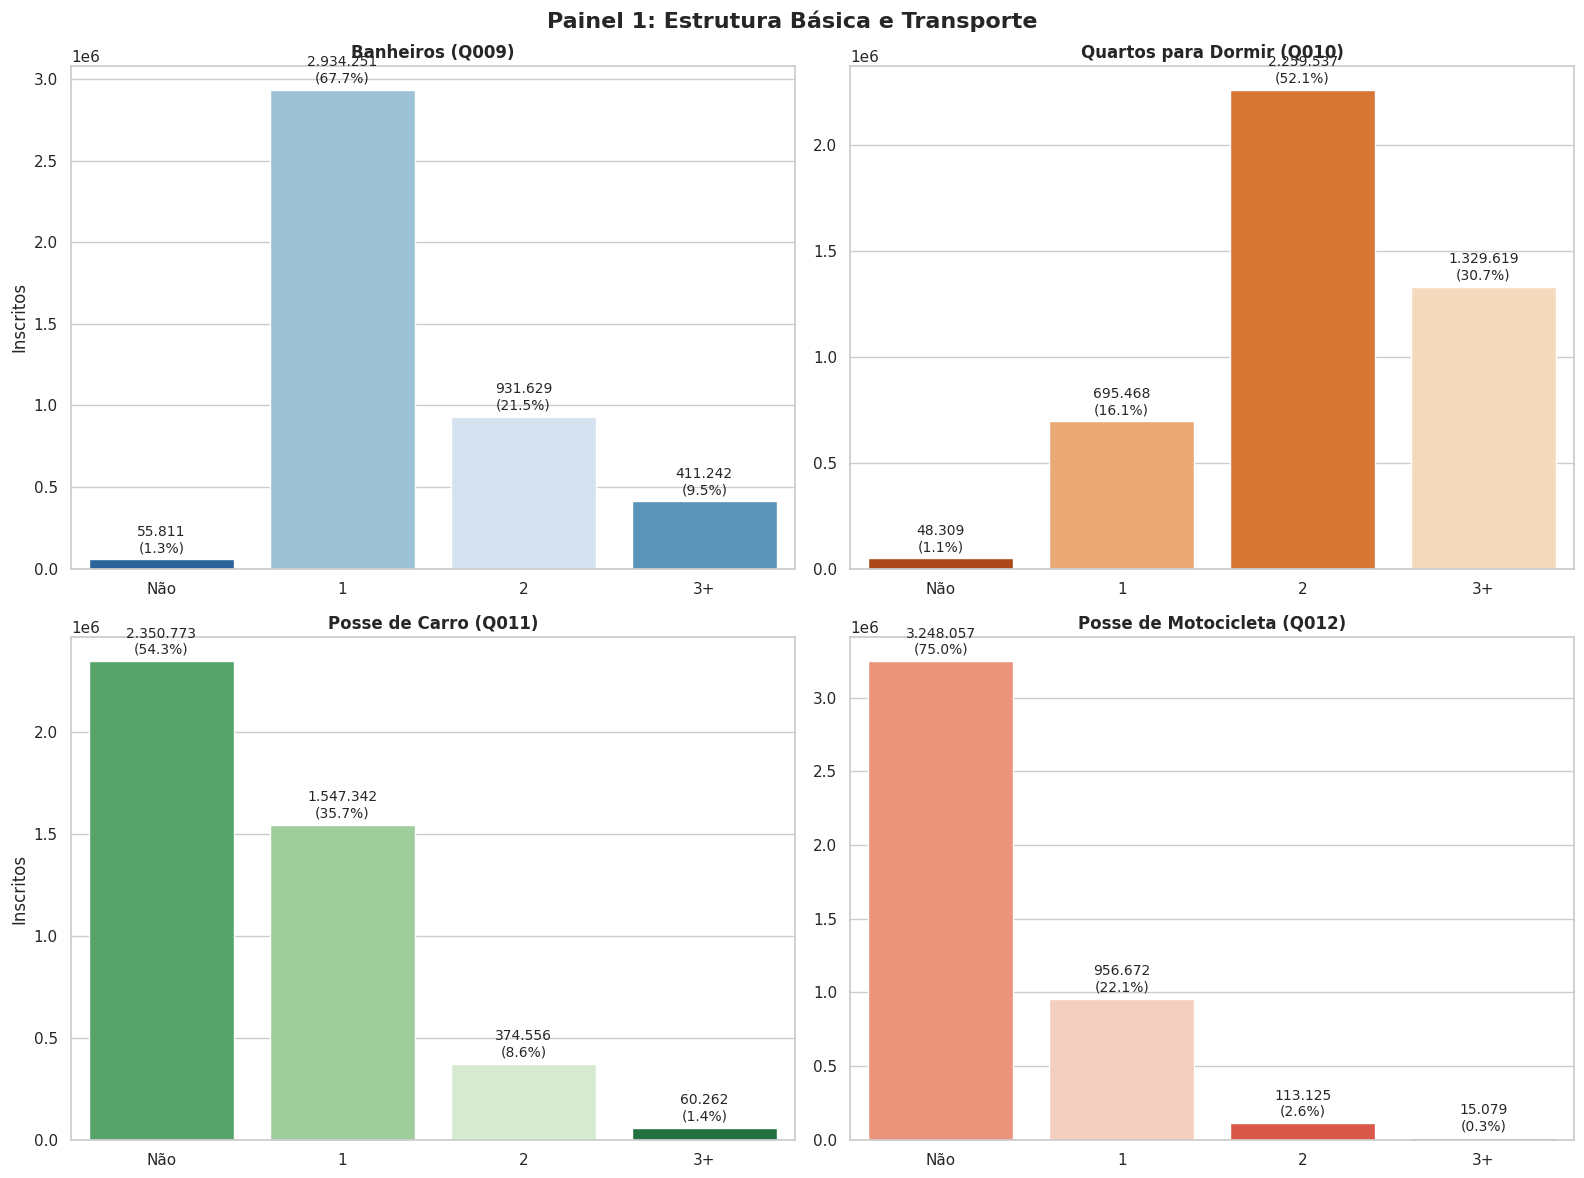

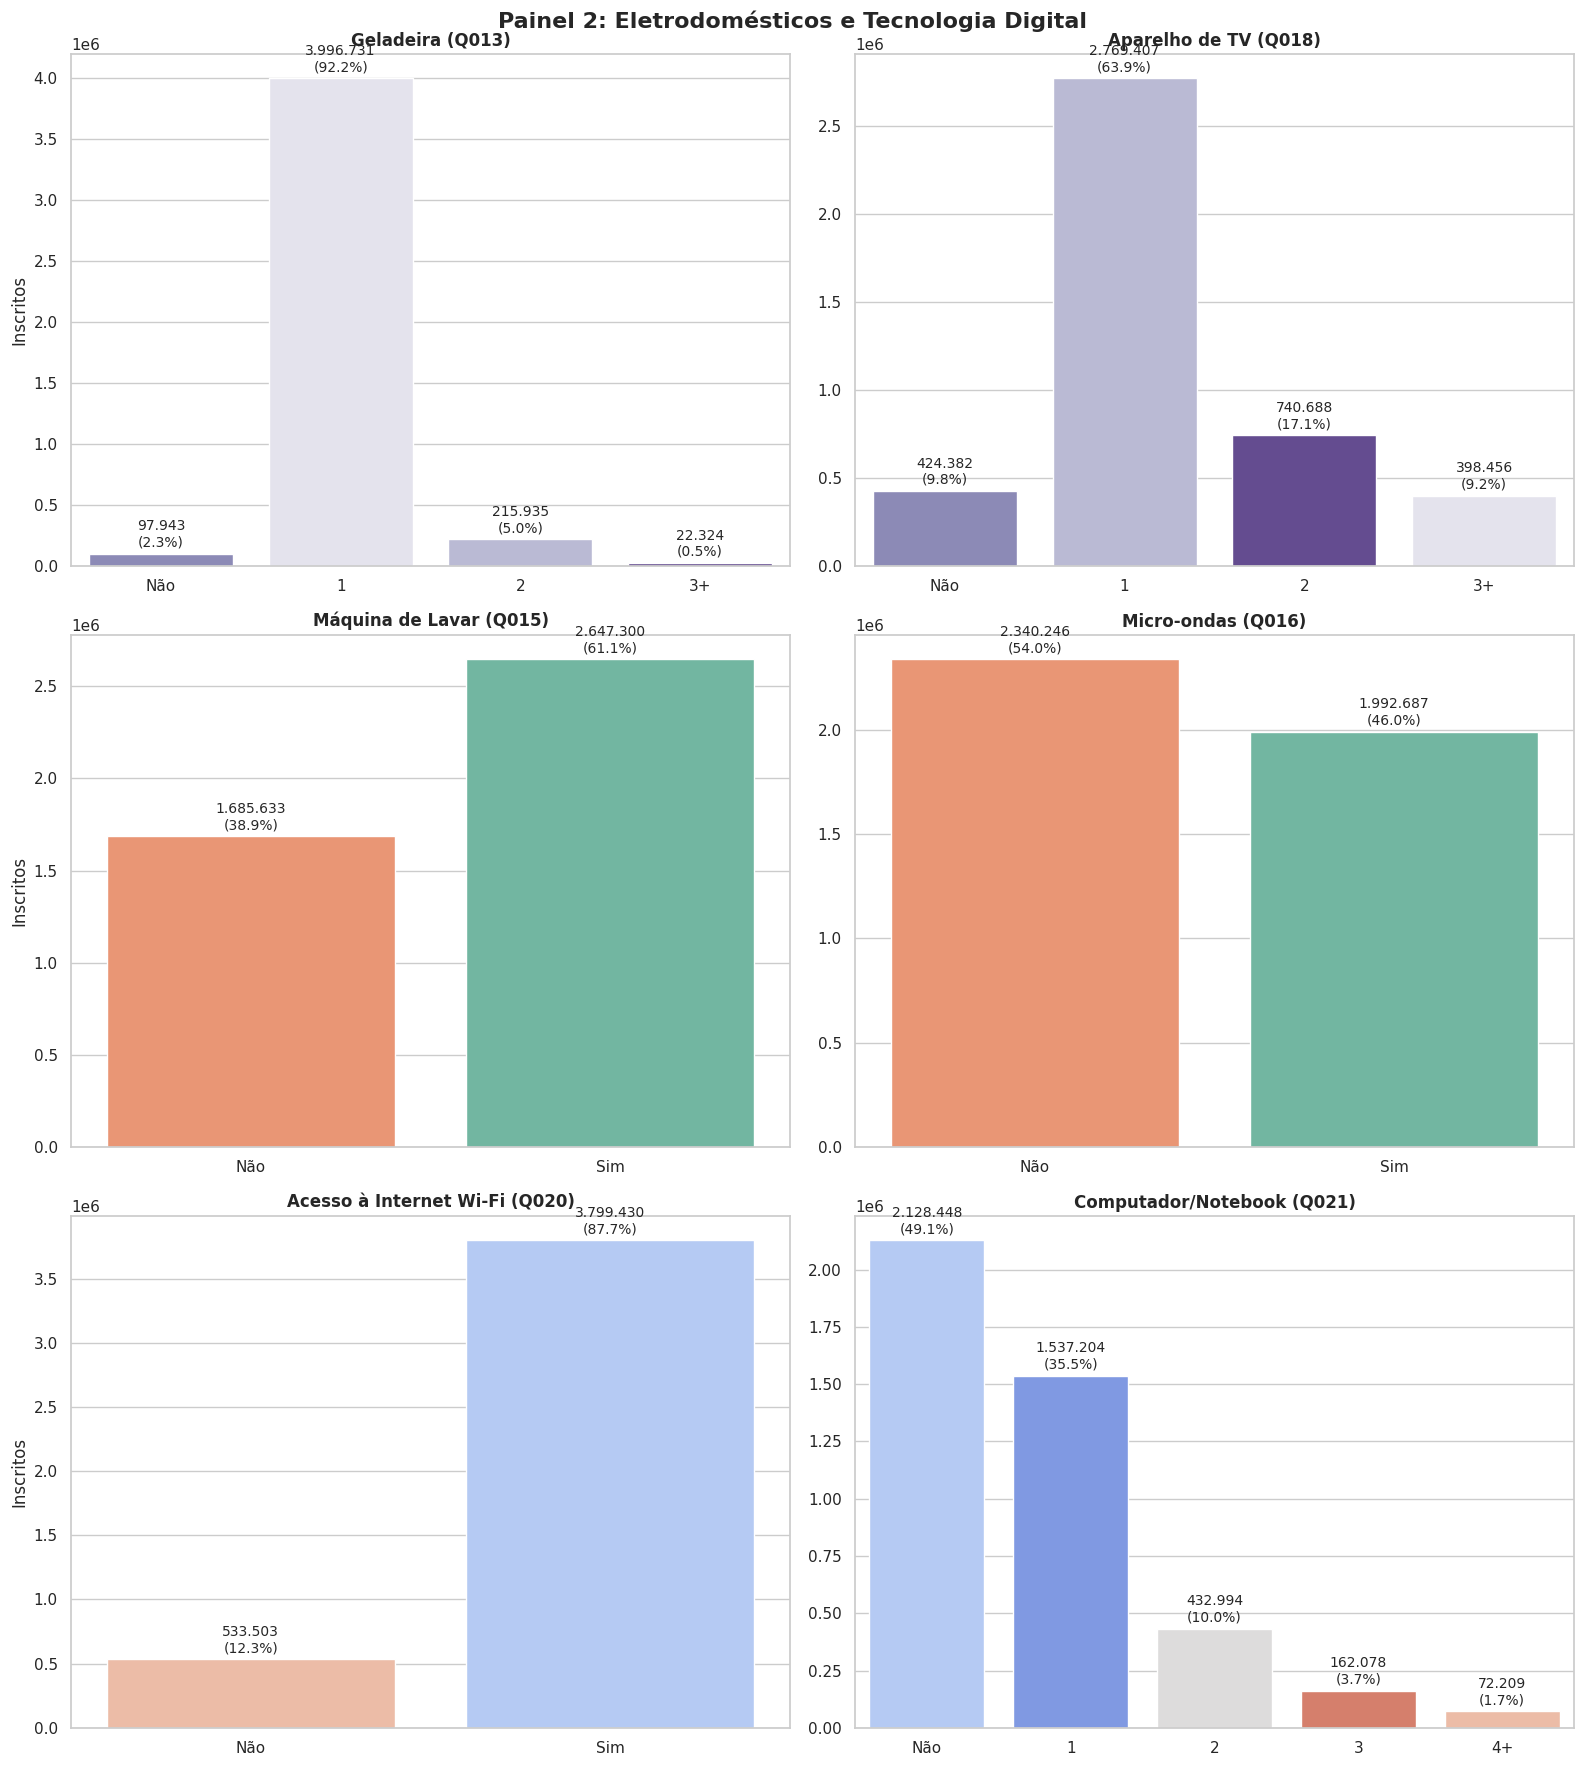

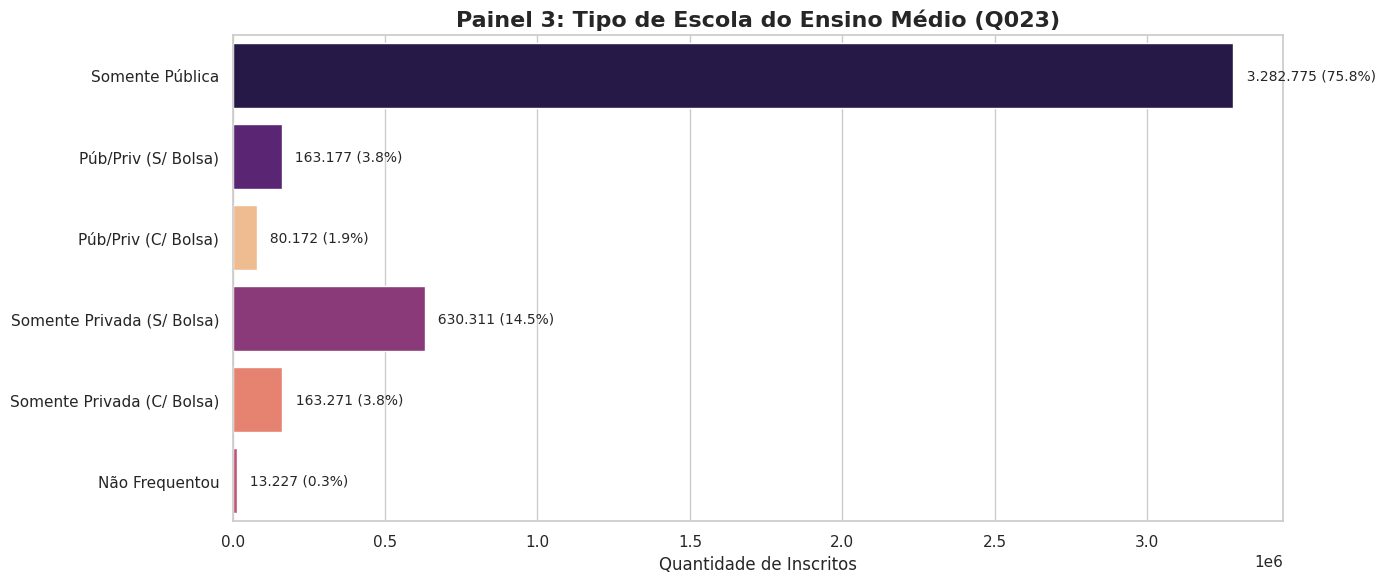

In [6]:
# ==========================================
# ANÁLISE DE INFRAESTRUTURA E ESCOLARIDADE (Dashboards Q009 a Q023)
# ==========================================

sns.set_theme(style="whitegrid")
total_alunos = len(df_part_limpo)

# 1. Número absoluto formatado + Porcentagem
def adicionar_valores_br(ax, total, orientacao='v'):
    for container in ax.containers:
        if orientacao == 'v':
            # Vertical
            ax.bar_label(container,
                         fmt=lambda x: f"{int(x):,}".replace(",", ".") + f"\n({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)
        else:
            # Horizontal
            ax.bar_label(container,
                         fmt=lambda x: f"  {int(x):,}".replace(",", ".") + f" ({(x/total)*100:.1f}%)" if x > 0 else "",
                         padding=3, fontsize=10)

# 2. Mapeamentos com base no Dicionário Oficial
mapa_quant_padrao = {'A': 'Não', 'B': '1', 'C': '2', 'D': '3+'}
mapa_quant_ext = {'A': 'Não', 'B': '1', 'C': '2', 'D': '3', 'E': '4+'} # Específico para PC e Celular
mapa_sim_nao = {'A': 'Não', 'B': 'Sim'}

# "Traduções"
df_part_limpo['DESC_Q009'] = df_part_limpo['Q009'].map(mapa_quant_padrao) # Banheiro
df_part_limpo['DESC_Q010'] = df_part_limpo['Q010'].map(mapa_quant_padrao) # Quarto
df_part_limpo['DESC_Q011'] = df_part_limpo['Q011'].map(mapa_quant_padrao) # Carro
df_part_limpo['DESC_Q012'] = df_part_limpo['Q012'].map(mapa_quant_padrao) # Moto

df_part_limpo['DESC_Q013'] = df_part_limpo['Q013'].map(mapa_quant_padrao) # Geladeira
df_part_limpo['DESC_Q015'] = df_part_limpo['Q015'].map(mapa_sim_nao)       # Máquina de Lavar
df_part_limpo['DESC_Q016'] = df_part_limpo['Q016'].map(mapa_sim_nao)       # Micro-ondas
df_part_limpo['DESC_Q018'] = df_part_limpo['Q018'].map(mapa_quant_padrao) # TV

df_part_limpo['DESC_Q020'] = df_part_limpo['Q020'].map(mapa_sim_nao)       # Internet
df_part_limpo['DESC_Q021'] = df_part_limpo['Q021'].map(mapa_quant_ext)     # PC
df_part_limpo['DESC_Q022'] = df_part_limpo['Q022'].map(mapa_quant_ext)     # Celular

mapa_q023 = {
    'A': 'Somente Pública', 'B': 'Púb/Priv (S/ Bolsa)', 'C': 'Púb/Priv (C/ Bolsa)',
    'D': 'Somente Privada (S/ Bolsa)', 'E': 'Somente Privada (C/ Bolsa)', 'F': 'Não Frequentou'
}
df_part_limpo['DESC_Q023'] = df_part_limpo['Q023'].map(mapa_q023)

# ---------------------------------------------------------
# PAINEL 1: Estrutura Básica e Transporte
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Painel 1: Estrutura Básica e Transporte', fontsize=16, fontweight='bold')
ordem_padrao = ['Não', '1', '2', '3+']

sns.countplot(data=df_part_limpo, x='DESC_Q009', hue='DESC_Q009', order=ordem_padrao, palette='Blues', ax=axes[0,0], legend=False)
axes[0,0].set_title('Banheiros (Q009)', fontweight='bold')
axes[0,0].set_ylabel('Inscritos'); axes[0,0].set_xlabel('')
adicionar_valores_br(axes[0,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q010', hue='DESC_Q010', order=ordem_padrao, palette='Oranges', ax=axes[0,1], legend=False)
axes[0,1].set_title('Quartos para Dormir (Q010)', fontweight='bold')
axes[0,1].set_ylabel(''); axes[0,1].set_xlabel('')
adicionar_valores_br(axes[0,1], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q011', hue='DESC_Q011', order=ordem_padrao, palette='Greens', ax=axes[1,0], legend=False)
axes[1,0].set_title('Posse de Carro (Q011)', fontweight='bold')
axes[1,0].set_ylabel('Inscritos'); axes[1,0].set_xlabel('')
adicionar_valores_br(axes[1,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q012', hue='DESC_Q012', order=ordem_padrao, palette='Reds', ax=axes[1,1], legend=False)
axes[1,1].set_title('Posse de Motocicleta (Q012)', fontweight='bold')
axes[1,1].set_ylabel(''); axes[1,1].set_xlabel('')
adicionar_valores_br(axes[1,1], total_alunos, orientacao='v')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 2: Eletrodomésticos e Tecnologia Digital
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(3, 2, figsize=(16, 18))
fig2.suptitle('Painel 2: Eletrodomésticos e Tecnologia Digital', fontsize=16, fontweight='bold')

ordem_ext = ['Não', '1', '2', '3', '4+']
ordem_sim_nao = ['Não', 'Sim']

sns.countplot(data=df_part_limpo, x='DESC_Q013', hue='DESC_Q013', order=ordem_padrao, palette='Purples', ax=axes2[0,0], legend=False)
axes2[0,0].set_title('Geladeira (Q013)', fontweight='bold')
axes2[0,0].set_ylabel('Inscritos'); axes2[0,0].set_xlabel('')
adicionar_valores_br(axes2[0,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q018', hue='DESC_Q018', order=ordem_padrao, palette='Purples', ax=axes2[0,1], legend=False)
axes2[0,1].set_title('Aparelho de TV (Q018)', fontweight='bold')
axes2[0,1].set_ylabel(''); axes2[0,1].set_xlabel('')
adicionar_valores_br(axes2[0,1], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q015', hue='DESC_Q015', order=ordem_sim_nao, palette='Set2', ax=axes2[1,0], legend=False)
axes2[1,0].set_title('Máquina de Lavar (Q015)', fontweight='bold')
axes2[1,0].set_ylabel('Inscritos'); axes2[1,0].set_xlabel('')
adicionar_valores_br(axes2[1,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q016', hue='DESC_Q016', order=ordem_sim_nao, palette='Set2', ax=axes2[1,1], legend=False)
axes2[1,1].set_title('Micro-ondas (Q016)', fontweight='bold')
axes2[1,1].set_ylabel(''); axes2[1,1].set_xlabel('')
adicionar_valores_br(axes2[1,1], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q020', hue='DESC_Q020', order=ordem_sim_nao, palette='coolwarm', ax=axes2[2,0], legend=False)
axes2[2,0].set_title('Acesso à Internet Wi-Fi (Q020)', fontweight='bold')
axes2[2,0].set_ylabel('Inscritos'); axes2[2,0].set_xlabel('')
adicionar_valores_br(axes2[2,0], total_alunos, orientacao='v')

sns.countplot(data=df_part_limpo, x='DESC_Q021', hue='DESC_Q021', order=ordem_ext, palette='coolwarm', ax=axes2[2,1], legend=False)
axes2[2,1].set_title('Computador/Notebook (Q021)', fontweight='bold')
axes2[2,1].set_ylabel(''); axes2[2,1].set_xlabel('')
adicionar_valores_br(axes2[2,1], total_alunos, orientacao='v')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PAINEL 3: Tipo de Escola do Ensino Médio (Q023)
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
ordem_escola = ['Somente Pública', 'Púb/Priv (S/ Bolsa)', 'Púb/Priv (C/ Bolsa)',
                'Somente Privada (S/ Bolsa)', 'Somente Privada (C/ Bolsa)', 'Não Frequentou']

ax_escola = sns.countplot(data=df_part_limpo, y='DESC_Q023', hue='DESC_Q023', order=ordem_escola, palette='magma', legend=False)
plt.title('Painel 3: Tipo de Escola do Ensino Médio (Q023)', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Inscritos', fontsize=12)
plt.ylabel('')

adicionar_valores_br(ax_escola, total_alunos, orientacao='h')

plt.tight_layout()
plt.show()


In [7]:
# ==========================================
# VISÃO GERAL DE RESULTADOS (Ranking com Todas as Competências)
# ==========================================


# 1. Filtrar apenas alunos válidos
# Usando as flags para garantir que o aluno esteve presente e teve a redação corrigida
df_res_validos = df_res_limpo[(df_res_limpo['TP_PRESENCA_MT'] == 1) & (df_res_limpo['TP_STATUS_REDACAO'] == 1)].copy()

# 2. Agrupar os Resultados por Município (TODAS as competências)
df_ranking = df_res_validos.groupby(['CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'SG_UF_PROVA']).agg(
    TOTAL_ALUNOS=('CO_MUNICIPIO_PROVA', 'count'),
    MEDIA_CN=('NU_NOTA_CN', 'mean'),
    MEDIA_CH=('NU_NOTA_CH', 'mean'),
    MEDIA_LC=('NU_NOTA_LC', 'mean'),
    MEDIA_MT=('NU_NOTA_MT', 'mean'),
    MEDIA_REDACAO=('NU_NOTA_REDACAO', 'mean')
).reset_index()

# 3. Média Geral da Cidade
# Soma as 5 disciplinas e divide por 5 para criar um indicador único de desempenho
df_ranking['MEDIA_GERAL'] = df_ranking[['MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC', 'MEDIA_MT', 'MEDIA_REDACAO']].mean(axis=1)

# 4. Extremos Absolutos (Focando na Média Geral)
# Sem filtro de corte populacional para preservação de "gênios"
top_10_cidades = df_ranking.nlargest(10, 'MEDIA_GERAL')
bottom_10_cidades = df_ranking.nsmallest(10, 'MEDIA_GERAL')

# Formatação visual do output para melhor leitura
colunas_exibicao = ['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TOTAL_ALUNOS', 'MEDIA_GERAL', 'MEDIA_REDACAO', 'MEDIA_MT', 'MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC']

print("TOP 10 CIDADES COM AS MAIORES MÉDIAS GERAIS:")
display(top_10_cidades[colunas_exibicao])

print("\n" + "="*100 + "\n")

print("TOP 10 CIDADES COM AS MENORES MÉDIAS GERAIS:")
display(bottom_10_cidades[colunas_exibicao])

TOP 10 CIDADES COM AS MAIORES MÉDIAS GERAIS:


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_ALUNOS,MEDIA_GERAL,MEDIA_REDACAO,MEDIA_MT,MEDIA_CN,MEDIA_CH,MEDIA_LC
1595,Veranópolis,RS,335,602.264716,766.507463,592.291642,529.585075,562.299104,560.640299
1339,Valinhos,SP,1604,600.107070,701.658354,610.262032,551.297943,569.483541,567.833479
938,Itaúna,MG,1026,600.015828,740.740741,602.707310,531.558674,563.610331,561.462086
1317,São José dos Campos,SP,9651,597.319575,710.767796,605.027634,541.071423,564.221936,565.509087
1541,Lajeado,RS,1043,597.278063,724.774688,599.534708,533.604314,564.587728,563.888878
1083,Vitória,ES,7027,595.714831,724.044400,591.439192,539.922954,562.709606,560.458005
1110,Niterói,RJ,10321,595.471832,730.200562,589.565720,533.695020,562.274838,561.623021
1029,Timóteo,MG,1185,594.889671,735.054852,593.347932,532.245823,558.496118,555.303629
1343,Vinhedo,SP,989,594.590637,705.763397,599.031648,541.702123,560.759151,565.696866
1493,Arroio do Meio,RS,136,594.394706,727.500000,591.980882,537.841176,554.300000,560.351471




TOP 10 CIDADES COM AS MENORES MÉDIAS GERAIS:


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_ALUNOS,MEDIA_GERAL,MEDIA_REDACAO,MEDIA_MT,MEDIA_CN,MEDIA_CH,MEDIA_LC
69,Japurá,AM,35,435.321714,474.285714,429.131429,423.442857,406.845714,442.902857
49,Benjamin Constant,AM,483,445.428696,493.374741,437.139337,430.763561,421.151967,444.713872
94,Tonantins,AM,109,448.453578,510.642202,428.453211,426.841284,424.440367,451.890826
76,Maraã,AM,74,455.459730,496.216216,438.272973,442.775676,439.670270,460.363514
86,Santa Isabel do Rio Negro,AM,83,457.423855,508.192771,429.510843,450.742169,438.691566,459.981928
81,Novo Aripuanã,AM,182,458.347143,510.769231,445.196703,441.743407,438.181868,455.844505
163,Prainha,PA,319,459.376113,547.398119,441.235110,439.387461,421.451724,447.408150
45,Atalaia do Norte,AM,106,460.674906,547.169811,435.033019,421.439623,433.321698,466.410377
87,Santo Antônio do Içá,AM,226,461.432212,537.876106,441.627876,435.942035,438.703982,453.011062
95,Uarini,AM,54,461.932222,516.666667,447.529630,433.774074,444.079630,467.611111


In [8]:
# ==========================================
# AGRUPAMENTO E MERGE (Síntese para Camada Silver)
# ==========================================

# ---------------------------------------------------------
# PASSO 1: Indicadores Socioeconômicos (Flags Binárias)
# ---------------------------------------------------------
# 1 = Não tem internet (A) / 0 = Tem
df_part_limpo['FLAG_SEM_INTERNET'] = np.where(df_part_limpo['Q020'] == 'A', 1, 0)

# 1 = Não tem computador (A) / 0 = Tem
df_part_limpo['FLAG_SEM_PC'] = np.where(df_part_limpo['Q021'] == 'A', 1, 0)

# 1 = Estudou SOMENTE em escola pública (A) / 0 = Outros
df_part_limpo['FLAG_ESCOLA_PUBLICA'] = np.where(df_part_limpo['Q023'] == 'A', 1, 0)

# ---------------------------------------------------------
# PASSO 2: Participantes por Cidade
# ---------------------------------------------------------
print("Agregando dados socioeconômicos por município...")
df_cidades_perfil = df_part_limpo.groupby(['CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA', 'SG_UF_PROVA']).agg(
    TOTAL_INSCRITOS=('CO_MUNICIPIO_PROVA', 'count'),
    PERC_SEM_INTERNET=('FLAG_SEM_INTERNET', 'mean'), # A média de zeros e uns dá a porcentagem (0.0 a 1.0)
    PERC_SEM_PC=('FLAG_SEM_PC', 'mean'),
    PERC_ESCOLA_PUBLICA=('FLAG_ESCOLA_PUBLICA', 'mean')
).reset_index()

df_cidades_perfil['PERC_SEM_INTERNET'] *= 100
df_cidades_perfil['PERC_SEM_PC'] *= 100
df_cidades_perfil['PERC_ESCOLA_PUBLICA'] *= 100

# ---------------------------------------------------------
# PASSO 3: Agrupar Resultados (Notas e Abstenção) por Cidade
# ---------------------------------------------------------


# Apenas quem teve as notas validadas (Para não derrubar a média com zeros de faltantes)
df_res_presentes = df_res_limpo[(df_res_limpo['TP_PRESENCA_MT'] == 1) & (df_res_limpo['TP_STATUS_REDACAO'] == 1)].copy()

df_cidades_notas = df_res_presentes.groupby('CO_MUNICIPIO_PROVA').agg(
    TOTAL_PRESENTES=('CO_MUNICIPIO_PROVA', 'count'),
    MEDIA_CN=('NU_NOTA_CN', 'mean'),
    MEDIA_CH=('NU_NOTA_CH', 'mean'),
    MEDIA_LC=('NU_NOTA_LC', 'mean'),
    MEDIA_MT=('NU_NOTA_MT', 'mean'),
    MEDIA_REDACAO=('NU_NOTA_REDACAO', 'mean')
).reset_index()

# Média Geral da Cidade
df_cidades_notas['MEDIA_GERAL'] = df_cidades_notas[['MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC', 'MEDIA_MT', 'MEDIA_REDACAO']].mean(axis=1)

# ---------------------------------------------------------
# PASSO 4: Merge das Bases (INNER JOIN)
# ---------------------------------------------------------

df_master_cidades = pd.merge(df_cidades_perfil, df_cidades_notas, on='CO_MUNICIPIO_PROVA', how='inner')

# Taxa de Abstenção da Cidade
df_master_cidades['TAXA_ABSTENCAO'] = (1 - (df_master_cidades['TOTAL_PRESENTES'] / df_master_cidades['TOTAL_INSCRITOS'])) * 100

print(f"Total de Municípios analisados: {len(df_master_cidades)}\n")

# Visão final do Dataset preparado
colunas_visao = ['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TOTAL_INSCRITOS', 'PERC_SEM_PC', 'PERC_ESCOLA_PUBLICA', 'MEDIA_GERAL', 'TAXA_ABSTENCAO']
display(df_master_cidades[colunas_visao].head())

Agregando dados socioeconômicos por município...
Total de Municípios analisados: 1753



,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_INSCRITOS,PERC_SEM_PC,PERC_ESCOLA_PUBLICA,MEDIA_GERAL,TAXA_ABSTENCAO
0,Alta Floresta D'Oeste,RO,471,54.140127,98.513800,528.108469,34.819533
1,Ariquemes,RO,2505,47.105788,88.662675,536.427346,40.439122
2,Cacoal,RO,2497,40.728875,73.127753,539.397713,34.160993
3,Cerejeiras,RO,414,47.342995,95.652174,519.465600,39.613527
4,Colorado do Oeste,RO,431,31.786543,96.751740,537.969703,29.698376


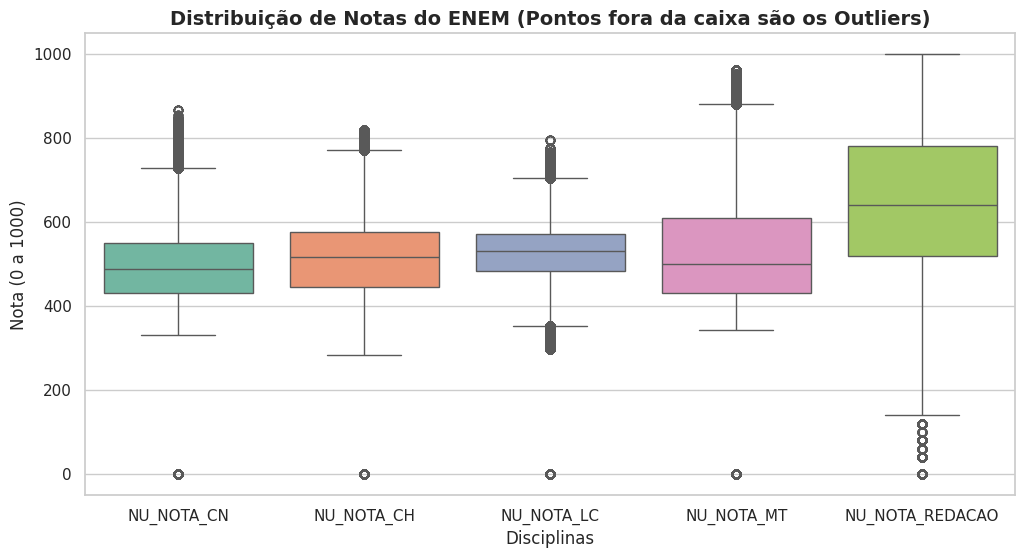

,SG_UF_PROVA,NO_MUNICIPIO_PROVA,NOTA_MAXIMA_ISOLADA
1212,RJ,Macaé,859.80
1698,SP,São José dos Campos,852.94
1100,PI,Teresina,851.05
1702,SP,São Paulo,849.72
1706,SP,Taboão da Serra,847.90
958,PB,João Pessoa,846.24
447,GO,Goiânia,845.32
1089,PI,Parnaíba,844.86
1049,PE,Recife,844.56
551,MA,São Luís,844.46


,SG_UF_PROVA,NO_MUNICIPIO_PROVA,MEDIA_GLOBAL_CIDADE
71,AM,Japurá,343.658155
57,AM,Canutama,423.516622
70,AM,Itamarati,423.554615
51,AM,Benjamin Constant,424.870848
78,AM,Maraã,426.680099
96,AM,Tonantins,428.924327
56,AM,Caapiranga,429.002733
72,AM,Jutaí,434.720965
83,AM,Novo Aripuanã,436.035374
97,AM,Uarini,436.964491


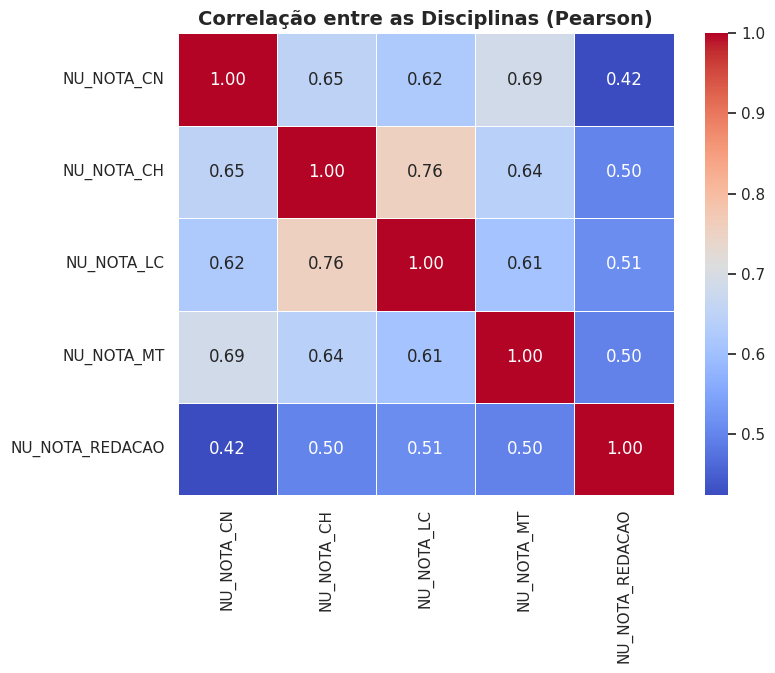

In [9]:
# ==========================================
#  OVERVIEW E ESTATÍSTICA DE RESULTADOS
# ==========================================


sns.set_theme(style="whitegrid")

# 1. Definindo as colunas de notas
notas_cols = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Média Geral por Aluno (Para podermos avaliar todas as competências juntas)
df_res_limpo['MEDIA_GERAL_ALUNO'] = df_res_limpo[notas_cols].mean(axis=1)

# ---------------------------------------------------------
# GRÁFICO 1: Distribuição e Outliers (Boxplot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_res_limpo[notas_cols], palette='Set2')
plt.title('Distribuição de Notas do ENEM (Pontos fora da caixa são os Outliers)', fontsize=14, fontweight='bold')
plt.ylabel('Nota (0 a 1000)')
plt.xlabel('Disciplinas')
plt.show()

# ---------------------------------------------------------
# TABELA 1: Caçando os Maiores Outliers (Gênios Isolados)
# ---------------------------------------------------------

# Agrupamos por cidade pegando a nota MÁXIMA que algum aluno tirou lá dentro
cidades_outliers_altos = df_res_limpo.groupby(['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA'])['MEDIA_GERAL_ALUNO'].max().reset_index()
cidades_outliers_altos = cidades_outliers_altos.sort_values(by='MEDIA_GERAL_ALUNO', ascending=False).head(10)
# Renomeando para ficar claro na apresentação
cidades_outliers_altos.rename(columns={'MEDIA_GERAL_ALUNO': 'NOTA_MAXIMA_ISOLADA'}, inplace=True)
display(cidades_outliers_altos)

# ---------------------------------------------------------
# TABELA 2: Municípios com as Menores Médias Globais
# ---------------------------------------------------------

# Aqui pegamos a MÉDIA da cidade para ver o desempenho real do município
cidades_outliers_baixos = df_res_limpo.groupby(['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA'])['MEDIA_GERAL_ALUNO'].mean().reset_index()
cidades_outliers_baixos = cidades_outliers_baixos.sort_values(by='MEDIA_GERAL_ALUNO', ascending=True).head(10)
cidades_outliers_baixos.rename(columns={'MEDIA_GERAL_ALUNO': 'MEDIA_GLOBAL_CIDADE'}, inplace=True)
display(cidades_outliers_baixos)

# ---------------------------------------------------------
# GRÁFICO 2: Heatmap de Correlação
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
correlacao_notas = df_res_limpo[notas_cols].corr()
sns.heatmap(correlacao_notas, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre as Disciplinas (Pearson)', fontsize=14, fontweight='bold')
plt.show()

>>> TOP 5 CIDADES COM MAIOR EXCLUSÃO DIGITAL <<<


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_INSCRITOS,INDICE_EXCLUSAO,MEDIA_GERAL
48,Barreirinha,AM,839,89.272944,465.905187
69,Japurá,AM,171,89.181287,435.321714
49,Benjamin Constant,AM,1009,88.206145,445.428696
33,Porto Walter,AC,197,83.502538,464.254000
41,Alvarães,AM,288,83.333333,468.935267


/tmp/ipykernel_2150/1195970209.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(data=df_extremos, x='PERFIL', y='MEDIA_GERAL', palette=['#d62728', '#1f77b4'])


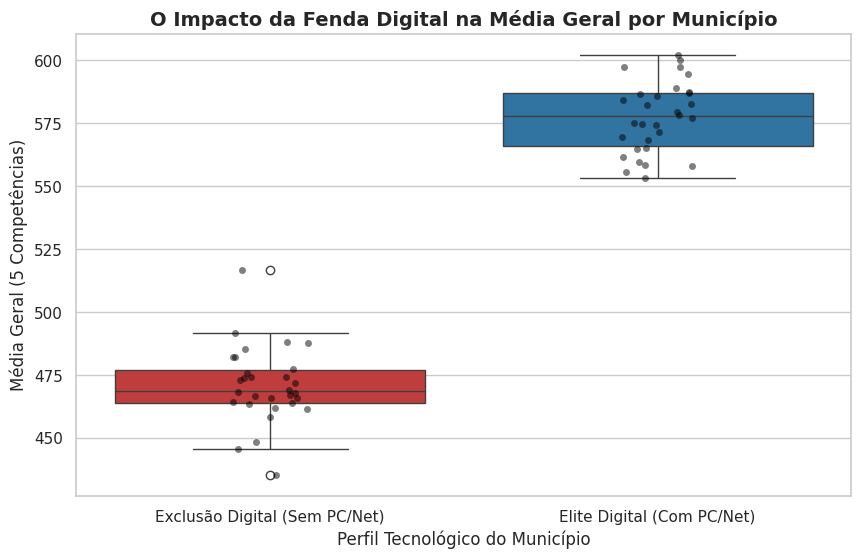

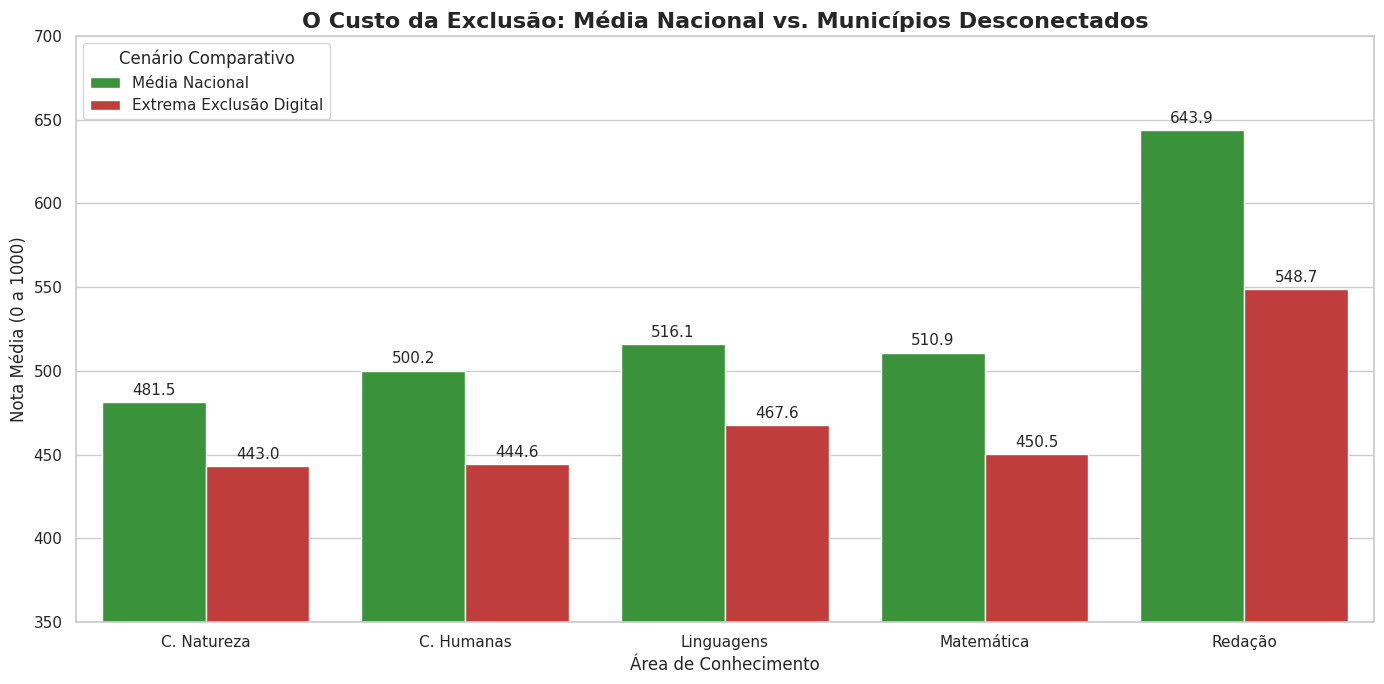

In [10]:
# ==========================================
# A FENDA DIGITAL (O Impacto em Todas as Competências)
# ==========================================

# 1. Utilizando a Camada Silver
df_analise = df_master_cidades.copy()

# 2. Índice de Exclusão (Média entre a falta de PC e falta de Internet)
df_analise['INDICE_EXCLUSAO'] = (df_analise['PERC_SEM_INTERNET'] + df_analise['PERC_SEM_PC']) / 2

# 3. Top 30 extremos
cidades_excluidas = df_analise.sort_values(by='INDICE_EXCLUSAO', ascending=False).head(30)
cidades_excluidas['PERFIL'] = 'Exclusão Digital (Sem PC/Net)'

cidades_conectadas = df_analise.sort_values(by='INDICE_EXCLUSAO', ascending=True).head(30)
cidades_conectadas['PERFIL'] = 'Elite Digital (Com PC/Net)'

# Unindo os dois grupos
df_extremos = pd.concat([cidades_excluidas, cidades_conectadas])

print(">>> TOP 5 CIDADES COM MAIOR EXCLUSÃO DIGITAL <<<")
display(cidades_excluidas[['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TOTAL_INSCRITOS', 'INDICE_EXCLUSAO', 'MEDIA_GERAL']].head())

# ---------------------------------------------------------
# DATA VIZ 1: O Boxplot da Média Geral
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Médias GERAIS dos dois grupos
ax1 = sns.boxplot(data=df_extremos, x='PERFIL', y='MEDIA_GERAL', palette=['#d62728', '#1f77b4'])
sns.stripplot(data=df_extremos, x='PERFIL', y='MEDIA_GERAL', color='black', alpha=0.5, jitter=True)

plt.title('O Impacto da Fenda Digital na Média Geral por Município', fontsize=14, fontweight='bold')
plt.xlabel('Perfil Tecnológico do Município', fontsize=12)
plt.ylabel('Média Geral (5 Competências)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# DATA VIZ 2: Barplot 5 Competências
# ---------------------------------------------------------
notas_cols = ['MEDIA_CN', 'MEDIA_CH', 'MEDIA_LC', 'MEDIA_MT', 'MEDIA_REDACAO']
nomes_amigaveis = ['C. Natureza', 'C. Humanas', 'Linguagens', 'Matemática', 'Redação']

#média nacional absoluta
media_nacional = df_analise[notas_cols].mean()

# média das 30 cidades mais excluídas
media_excluidas = cidades_excluidas[notas_cols].mean()


df_comparativo = pd.DataFrame({
    'Competência': nomes_amigaveis,
    'Média Nacional': media_nacional.values,
    'Extrema Exclusão Digital': media_excluidas.values
})

# formato do Seaborn
df_melted = df_comparativo.melt(id_vars='Competência', var_name='Cenário', value_name='Nota Média')

plt.figure(figsize=(14, 7))
ax2 = sns.barplot(data=df_melted, x='Competência', y='Nota Média', hue='Cenário', palette=['#2ca02c', '#d62728'])

plt.title('O Custo da Exclusão: Média Nacional vs. Municípios Desconectados', fontsize=16, fontweight='bold')
plt.ylabel('Nota Média (0 a 1000)', fontsize=12)
plt.xlabel('Área de Conhecimento', fontsize=12)
plt.ylim(350, 700) # Ajuste de eixo para destacar o Gap

# valores nas barras
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f', padding=3, fontsize=11)

plt.legend(title='Cenário Comparativo', fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

,NO_MUNICIPIO_PROVA,SG_UF_PROVA,PERC_RENDA_BAIXA,PERC_MAE_QUALIFICADA,MEDIA_GERAL
0,Alta Floresta D'Oeste,RO,67.515924,20.594480,528.108469
1,Ariquemes,RO,62.834331,28.902196,536.427346
2,Cacoal,RO,60.312375,30.837004,539.397713
3,Cerejeiras,RO,63.285024,22.463768,519.465600
4,Colorado do Oeste,RO,57.076566,26.218097,537.969703


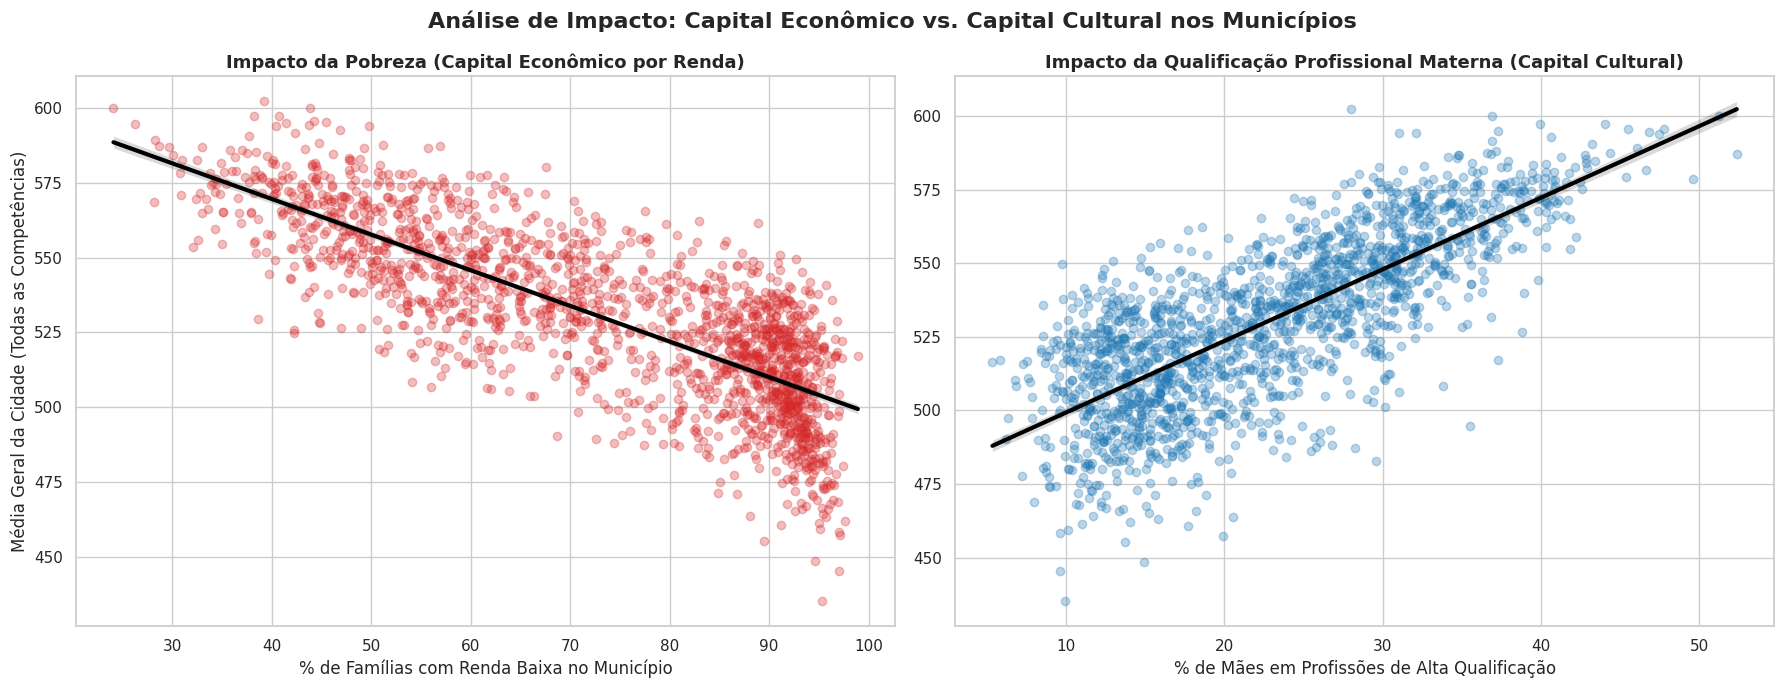



>>> RESULTADOS DA REGRESSÃO (IMPACTO ESTATÍSTICO REAL) <<<
Nota Base (Intercepto Teórico): 571.2 pontos
Impacto da Renda: Para cada 1% a MAIS de famílias com Renda Baixa, a nota da cidade VARIARÁ -0.82 pontos.
Impacto da Profissão: Para cada 1% a MAIS de Mães Qualificadas, a nota da cidade VARIARÁ 0.84 pontos.

Arquivo ouro salvo em: /content/drive/MyDrive/Projeto_ENEM/Base_Consolidada_ML.csv
O Dataset final conta com 1753 municípios integrados e pronto para os modelos da Etapa 3.


In [11]:
# ==========================================
# ANÁLISE MULTIDIMENSIONAL, REGRESSÃO MÚLTIPLA E EXPORTAÇÃO
# ==========================================

from sklearn.linear_model import LinearRegression


# ---------------------------------------------------------
# PASSO 1: Feature Engineering na Base de Alunos
# ---------------------------------------------------------
# Flag de Renda Baixa (Categorias A, B, C, D do questionário de Renda Familiar Q007)
df_part_limpo['FLAG_RENDA_BAIXA'] = np.where(df_part_limpo['Q007'].isin(['A', 'B', 'C', 'D']), 1, 0)

# Flags de Alta Qualificação Profissional (Categorias D e E das perguntas Q003 e Q004)
df_part_limpo['FLAG_PAI_QUALIFICADO'] = np.where(df_part_limpo['Q003'].isin(['D', 'E']), 1, 0)
df_part_limpo['FLAG_MAE_QUALIFICADA'] = np.where(df_part_limpo['Q004'].isin(['D', 'E']), 1, 0)

# ---------------------------------------------------------
# PASSO 2: Agrupamento por Município (Mudança de Granularidade)
# ---------------------------------------------------------

df_cidades_socio = df_part_limpo.groupby('CO_MUNICIPIO_PROVA').agg(
    TOTAL_INSCRITOS_SOCIO=('CO_MUNICIPIO_PROVA', 'count'),
    PERC_RENDA_BAIXA=('FLAG_RENDA_BAIXA', 'mean'),
    PERC_PAI_QUALIFICADO=('FLAG_PAI_QUALIFICADO', 'mean'),
    PERC_MAE_QUALIFICADA=('FLAG_MAE_QUALIFICADA', 'mean')
).reset_index()

df_cidades_socio['PERC_RENDA_BAIXA'] *= 100
df_cidades_socio['PERC_PAI_QUALIFICADO'] *= 100
df_cidades_socio['PERC_MAE_QUALIFICADA'] *= 100

# ---------------------------------------------------------
# PASSO 3: Geração da Base de Estudo Extremo
# ---------------------------------------------------------
# Unindo os perfis socioeconômicos com as notas consolidadas (df_master_cidades)
df_estudo_extremo = pd.merge(df_cidades_socio, df_master_cidades, on='CO_MUNICIPIO_PROVA', how='inner')

display(df_estudo_extremo[['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'PERC_RENDA_BAIXA', 'PERC_MAE_QUALIFICADA', 'MEDIA_GERAL']].head())

# ---------------------------------------------------------
# PASSO 4: DATA VIZ - Linhas de Tendência e Regressão Visual
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análise de Impacto: Capital Econômico vs. Capital Cultural nos Municípios', fontsize=16, fontweight='bold')

# Gráfico 1: Renda Familiar Baixa vs Desempenho (Tendência de Queda)
sns.regplot(data=df_estudo_extremo, x='PERC_RENDA_BAIXA', y='MEDIA_GERAL',
            scatter_kws={'alpha':0.3, 'color': '#d62728'}, line_kws={'color': 'black', 'linewidth': 3}, ax=axes[0])
axes[0].set_title('Impacto da Pobreza (Capital Econômico por Renda)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('% de Famílias com Renda Baixa no Município')
axes[0].set_ylabel('Média Geral da Cidade (Todas as Competências)')

# Gráfico 2: Qualificação da Mãe vs Desempenho (Tendência de Alta)
sns.regplot(data=df_estudo_extremo, x='PERC_MAE_QUALIFICADA', y='MEDIA_GERAL',
            scatter_kws={'alpha':0.3, 'color': '#1f77b4'}, line_kws={'color': 'black', 'linewidth': 3}, ax=axes[1])
axes[1].set_title('Impacto da Qualificação Profissional Materna (Capital Cultural)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% de Mães em Profissões de Alta Qualificação')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PASSO 5: MACHINE LEARNING - Ajuste do Modelo de Regressão Múltipla
# ---------------------------------------------------------
print("\n" + "="*50)
print("="*50)

# Definindo preditores (X) e alvo (y)
X = df_estudo_extremo[['PERC_RENDA_BAIXA', 'PERC_MAE_QUALIFICADA']]
y = df_estudo_extremo['MEDIA_GERAL']

modelo = LinearRegression()
modelo.fit(X, y)

# Exibição dos coeficientes gerados pela máquina
print("\n>>> RESULTADOS DA REGRESSÃO (IMPACTO ESTATÍSTICO REAL) <<<")
print(f"Nota Base (Intercepto Teórico): {modelo.intercept_:.1f} pontos")
print(f"Impacto da Renda: Para cada 1% a MAIS de famílias com Renda Baixa, a nota da cidade VARIARÁ {modelo.coef_[0]:.2f} pontos.")
print(f"Impacto da Profissão: Para cada 1% a MAIS de Mães Qualificadas, a nota da cidade VARIARÁ {modelo.coef_[1]:.2f} pontos.\n")

# ---------------------------------------------------------
# PASSO 6: PERSISTÊNCIA DOS DADOS - Exportação Final da Camada Silver
# ---------------------------------------------------------
print("="*80)
print("="*80)

caminho_saida = '/content/drive/MyDrive/Projeto_ENEM/Base_Consolidada_ML.csv'
df_estudo_extremo.to_csv(caminho_saida, sep=';', encoding='latin1', index=False)

print(f"Arquivo ouro salvo em: {caminho_saida}")
print(f"O Dataset final conta com {df_estudo_extremo.shape[0]} municípios integrados e pronto para os modelos da Etapa 3.")




Iniciando a modelagem não-supervisionada (Clustering)...

Dataset de ML criado: 7 features.
Divisão: Treino com 1314 cidades | Teste com 439 cidades.

Calculando métricas para Otimização (K=2 a 8)...


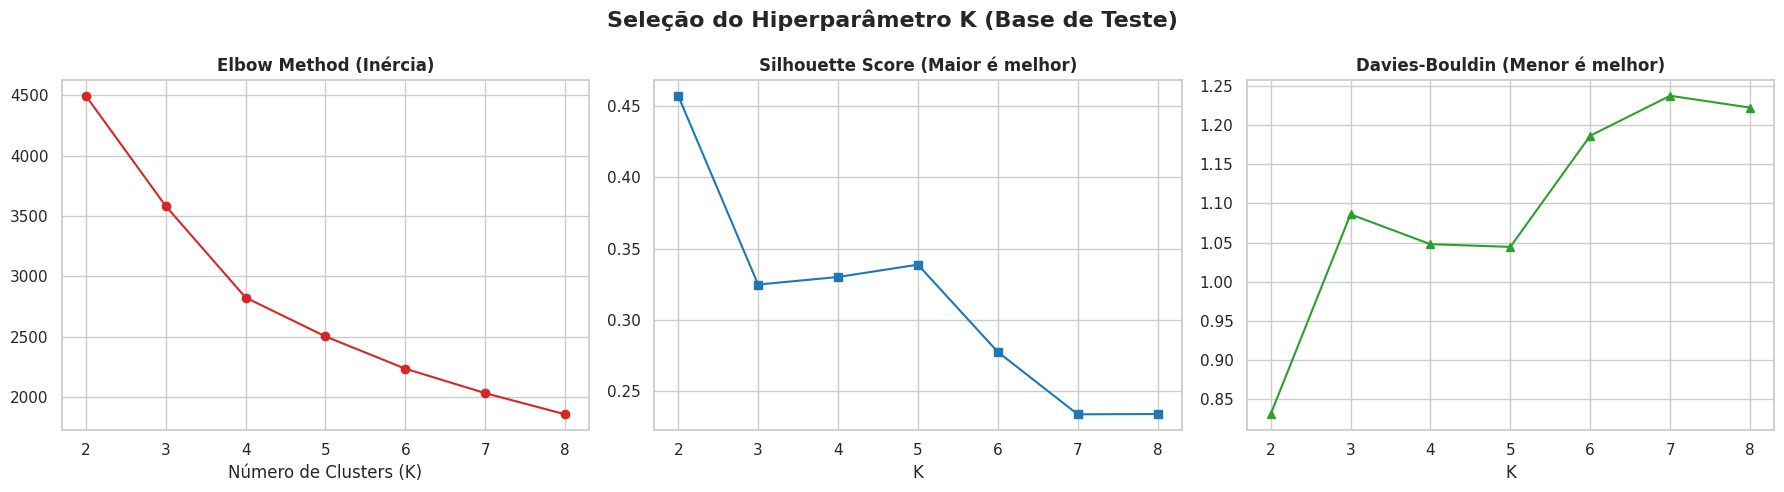

In [17]:
# ==========================================
# BLOCO 10: PREPARAÇÃO, SPLIT E TUNING (K-MEANS)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Iniciando a modelagem não-supervisionada (Clustering)...\n")

# 1. Definição do Escopo (INCLUINDO Renda e Capital Cultural)
features = [
    'PERC_SEM_INTERNET', 'PERC_SEM_PC', 'PERC_ESCOLA_PUBLICA',
    'PERC_RENDA_BAIXA', 'PERC_MAE_QUALIFICADA', # O Ouro que adicionamos
    'TAXA_ABSTENCAO', 'MEDIA_GERAL'
]

# Garantindo que estamos usando o df_estudo_extremo da etapa anterior
df_ml = df_estudo_extremo.copy()
X = df_ml[features].dropna().copy()
df_ml = df_ml.loc[X.index].copy()

# 2. Separação de Treino e Teste
X_train, X_test = train_test_split(X, test_size=0.25, random_state=42)
print(f"Dataset de ML criado: {X.shape[1]} features.")
print(f"Divisão: Treino com {X_train.shape[0]} cidades | Teste com {X_test.shape[0]} cidades.\n")

# 3. Tuning de Hiperparâmetros (Descobrindo o melhor K)
k_values = range(2, 9)
inertias, sil_test, db_test = [], [], []

print("Calculando métricas para Otimização (K=2 a 8)...")
for k in k_values:
    pipe = Pipeline([("scaler", StandardScaler()), ("kmeans", KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42))])
    pipe.fit(X_train)

    Xte_scaled = pipe.named_steps["scaler"].transform(X_test)
    labels_test = pipe.predict(X_test)

    inertias.append(pipe.named_steps["kmeans"].inertia_)
    sil_test.append(silhouette_score(Xte_scaled, labels_test))
    db_test.append(davies_bouldin_score(Xte_scaled, labels_test))

# 4. Painel de Otimização Visual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Seleção do Hiperparâmetro K (Base de Teste)", fontweight="bold", fontsize=16)

axes[0].plot(list(k_values), inertias, marker="o", color="#d62728")
axes[0].set_title("Elbow Method (Inércia)", fontweight="bold"); axes[0].set_xlabel("Número de Clusters (K)")

axes[1].plot(list(k_values), sil_test, marker="s", color="#1f77b4")
axes[1].set_title("Silhouette Score (Maior é melhor)", fontweight="bold"); axes[1].set_xlabel("K")

axes[2].plot(list(k_values), db_test, marker="^", color="#2ca02c")
axes[2].set_title("Davies-Bouldin (Menor é melhor)", fontweight="bold"); axes[2].set_xlabel("K")

plt.tight_layout()
plt.show()

GERANDO RELATÓRIO EXECUTIVO DE POLÍTICAS PÚBLICAS...

📌 DIAGNÓSTICO ESTATÍSTICO (Causa e Efeito):
- O modelo de regressão prova que a cada 1% a mais de pobreza na cidade, a nota cai -0.82 pontos.
- Em contrapartida, cada 1% a mais de mães qualificadas levanta a nota em +0.84 pontos.

🎯 PLANO DE AÇÃO (Foco do Ministério da Educação):
- A Clusterização identificou o 'Cluster 3' como a zona de alerta máximo nacional.
- Este grupo contém 113 municípios.
- Nestas cidades, a média de alunos sem computador chega a 82.2%. (Assumindo um K ótimo = 4)
- Sugestão de Política Pública: Direcionar subsídios de conectividade e bolsas de permanência prioritariamente para as 113 cidades deste cluster.



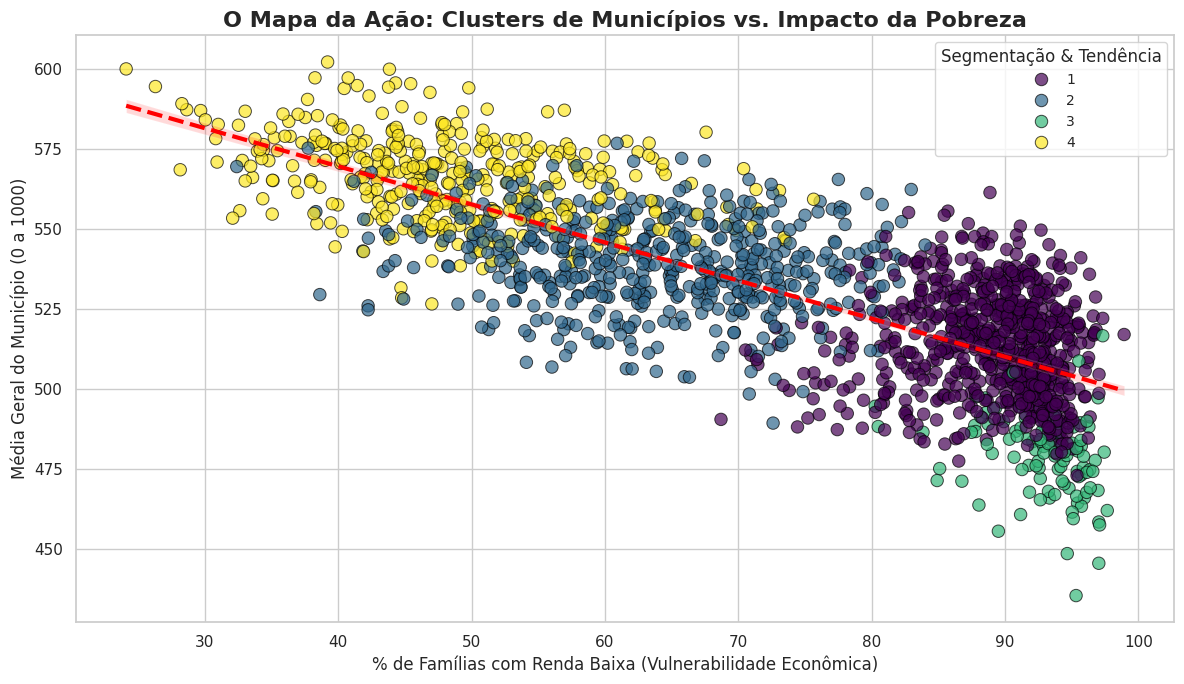


>>> LISTA DE AÇÃO IMEDIATA: Top 5 Municípios Críticos do Cluster 3 <<<


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,TOTAL_INSCRITOS,PERC_RENDA_BAIXA,PERC_SEM_PC,MEDIA_GERAL
69,Japurá,AM,171,95.321637,93.567251,435.321714
49,Benjamin Constant,AM,1009,97.026759,87.413280,445.428696
94,Tonantins,AM,281,94.661922,84.341637,448.453578
76,Maraã,AM,219,89.497717,64.840183,455.459730
86,Santa Isabel do Rio Negro,AM,206,97.087379,82.524272,457.423855


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("="*80)
print("GERANDO RELATÓRIO EXECUTIVO DE POLÍTICAS PÚBLICAS...")
print("="*80 + "\n")

# Re-applying the setup for df_ml and features as done in the previous cell cS2jlmms5t-y
# This ensures that df_ml is consistent and has the 'features' subset.
features = [
    'PERC_SEM_INTERNET', 'PERC_SEM_PC', 'PERC_ESCOLA_PUBLICA',
    'PERC_RENDA_BAIXA', 'PERC_MAE_QUALIFICADA',
    'TAXA_ABSTENCAO', 'MEDIA_GERAL'
]

# df_ml was already defined from df_estudo_extremo in a previous cell,
# but it's good practice to ensure it's consistent for this block.
# We also need to handle potential NaNs before scaling and clustering.
df_ml = df_estudo_extremo.copy() # Assuming df_estudo_extremo is available from previous cells

# Filter out NaNs and update df_ml accordingly, mirroring the X creation in cS2jlmms5t-y
X_for_clustering = df_ml[features].dropna().copy()
df_ml = df_ml.loc[X_for_clustering.index].copy()

# ---------------------------------------------------------
# FIX: Apply Clustering and add 'CLUSTER' column to df_ml
# ---------------------------------------------------------
# Choose an optimal K value (e.g., based on the plots from cell cS2jlmms5t-y)
# From the previous tuning, a K of 4 seems like a reasonable choice for demonstration.
optimal_k = 4

# Scale the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_for_clustering)

# Perform KMeans clustering
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
df_ml['CLUSTER'] = kmeans.fit_predict(X_scaled) + 1 # Add 1 to make clusters 1-indexed for better readability

# 1. A REGRESSÃO (O Diagnóstico)
# Reinstanciando a regressão para extrair os números exatos para o discurso
X_reg = df_ml[['PERC_RENDA_BAIXA', 'PERC_MAE_QUALIFICADA']]
y_reg = df_ml['MEDIA_GERAL']

modelo_final = LinearRegression()
modelo_final.fit(X_reg, y_reg)
impacto_pobreza = modelo_final.coef_[0]
impacto_cultura = modelo_final.coef_[1]

# 2. A CLUSTERIZAÇÃO (A Ação)
# Identificando automaticamente qual é o cluster mais vulnerável (maior pobreza)
perfil_clusters = df_ml.groupby("CLUSTER")[['PERC_RENDA_BAIXA', 'MEDIA_GERAL', 'PERC_SEM_PC']].mean()
cluster_critico = perfil_clusters['PERC_RENDA_BAIXA'].idxmax()
cidades_alvo = df_ml[df_ml['CLUSTER'] == cluster_critico]

# --- TEXTO DO RELATÓRIO EXECUTIVO NO TERMINAL ---
print(f"📌 DIAGNÓSTICO ESTATÍSTICO (Causa e Efeito):")
print(f"- O modelo de regressão prova que a cada 1% a mais de pobreza na cidade, a nota cai {impacto_pobreza:.2f} pontos.")
print(f"- Em contrapartida, cada 1% a mais de mães qualificadas levanta a nota em +{impacto_cultura:.2f} pontos.\n")

print(f"🎯 PLANO DE AÇÃO (Foco do Ministério da Educação):")
print(f"- A Clusterização identificou o 'Cluster {cluster_critico}' como a zona de alerta máximo nacional.")
print(f"- Este grupo contém {len(cidades_alvo)} municípios.")
print(f"- Nestas cidades, a média de alunos sem computador chega a {perfil_clusters.loc[cluster_critico, 'PERC_SEM_PC']:.1f}%. (Assumindo um K ótimo = 4)")
print(f"- Sugestão de Política Pública: Direcionar subsídios de conectividade e bolsas de permanência prioritariamente para as {len(cidades_alvo)} cidades deste cluster.\n")

# ---------------------------------------------------------
# DATA VIZ: O Gráfico Definitivo (Regressão + Clusterização Juntas)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Plotando os pontos coloridos por Cluster
ax = sns.scatterplot(
    data=df_ml,
    x='PERC_RENDA_BAIXA',
    y='MEDIA_GERAL',
    hue='CLUSTER',
    palette='viridis',
    alpha=0.7,
    s=80,
    edgecolor='black'
)

# Sobrepondo a linha de tendência da regressão linear simples (Renda vs Nota)
sns.regplot(
    data=df_ml,
    x='PERC_RENDA_BAIXA',
    y='MEDIA_GERAL',
    scatter=False,
    color='red',
    line_kws={'linewidth': 3, 'linestyle': '--', 'label': 'Linha de Regressão (Impacto da Pobreza)'},
    ax=ax
)

plt.title('O Mapa da Ação: Clusters de Municípios vs. Impacto da Pobreza', fontsize=16, fontweight='bold')
plt.xlabel('% de Famílias com Renda Baixa (Vulnerabilidade Econômica)', fontsize=12)
plt.ylabel('Média Geral do Município (0 a 1000)', fontsize=12)

# Ajustando as legendas
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Segmentação & Tendência', loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Exibindo as Top 5 cidades que mais precisam da política pública agora
print(f"\n>>> LISTA DE AÇÃO IMEDIATA: Top 5 Municípios Críticos do Cluster {cluster_critico} <<<")
display(cidades_alvo.sort_values(by='MEDIA_GERAL', ascending=True)[['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', 'TOTAL_INSCRITOS', 'PERC_RENDA_BAIXA', 'PERC_SEM_PC', 'MEDIA_GERAL']].head())

In [45]:
# ==========================================
# CÓDIGO DO INTEGRANTE CORRIGIDO: Mapeamento Ordinal
# ==========================================
import pandas as pd
import numpy as np

print("Aplicando mapeamento numérico (Ordinal Encoding) nas variáveis socioeconômicas...\n")

# Dicionários de mapeamento (0 = Pior condição socioeconômica -> Maior = Melhor condição)
map_renda = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8,
             'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16}

map_escolaridade = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': np.nan}

# Para o tipo de escola, a ordem reflete o poder aquisitivo presumido
map_escola = {'F': 0, 'A': 1, 'C': 2, 'E': 3, 'B': 4, 'D': 5}

map_bens_0_a_4 = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
map_bens_0_a_3 = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
map_binario = {'A': 0, 'B': 1}

# Aplicando os mapeamentos NO DATAFRAME DO NOSSO PROJETO (df_part_limpo)
df_part_limpo['Q007_num'] = df_part_limpo['Q007'].map(map_renda)
df_part_limpo['Q001_num'] = df_part_limpo['Q001'].map(map_escolaridade)
df_part_limpo['Q002_num'] = df_part_limpo['Q002'].map(map_escolaridade)
df_part_limpo['Q023_num'] = df_part_limpo['Q023'].map(map_escola)
df_part_limpo['Q021_num'] = df_part_limpo['Q021'].map(map_bens_0_a_4) # Computador
df_part_limpo['Q020_num'] = df_part_limpo['Q020'].map(map_binario)    # Wi-Fi
df_part_limpo['Q008_num'] = df_part_limpo['Q008'].map(map_bens_0_a_3) # Empregada
df_part_limpo['Q011_num'] = df_part_limpo['Q011'].map(map_bens_0_a_3) # Carro
df_part_limpo['Q009_num'] = df_part_limpo['Q009'].map(map_bens_0_a_3) # Banheiro

# A variável Q005 (Moradores) já é numérica, basta garantir o tipo correto
df_part_limpo['Q005_num'] = pd.to_numeric(df_part_limpo['Q005'], errors='coerce')

# 1. A SOLUÇÃO DO ERRO: Definindo explicitamente a lista de colunas numéricas
colunas_num = [
    'Q007_num', 'Q001_num', 'Q002_num', 'Q023_num',
    'Q021_num', 'Q020_num', 'Q008_num', 'Q011_num',
    'Q009_num', 'Q005_num'
]

# 2. Agregação por cidade amigável ao modelo
# Tiramos a média do peso dessas variáveis para cada cidade
df_cidades_agregado = df_part_limpo.groupby('CO_MUNICIPIO_PROVA')[colunas_num].mean().reset_index()

print("✅ Agregação realizada com sucesso! Visualizando a tabela pronta:")
display(df_cidades_agregado.head())

Aplicando mapeamento numérico (Ordinal Encoding) nas variáveis socioeconômicas...

✅ Agregação realizada com sucesso! Visualizando a tabela pronta:


,CO_MUNICIPIO_PROVA,Q007_num,Q001_num,Q002_num,Q023_num,Q021_num,Q020_num,Q008_num,Q011_num,Q009_num,Q005_num
0,1100015,3.129512,2.592326,3.280973,1.040340,0.571125,0.953291,0.142251,0.615711,1.282378,3.728238
1,1100023,3.512575,2.930243,3.742114,1.354890,0.684232,0.893014,0.134930,0.592016,1.362874,3.569661
2,1100049,3.736884,3.098617,3.704762,1.794954,0.807769,0.938726,0.156187,0.648378,1.386464,3.583500
3,1100056,3.362319,2.837989,3.577608,1.115942,0.657005,0.954106,0.152174,0.702899,1.405797,3.734300
4,1100064,3.846868,3.134565,3.760291,1.090487,0.856148,0.965197,0.164733,0.765661,1.410673,3.596288


In [46]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Supondo que você já rodou o código de encoding do passo anterior e tem o df pronto

# 1. Definimos a lista apenas com as colunas numéricas que acabamos de criar
colunas_para_escalar = [
    'Q007_num', 'Q001_num', 'Q002_num', 'Q023_num',
    'Q021_num', 'Q020_num', 'Q008_num', 'Q011_num',
    'Q009_num', 'Q005_num'
]

# 2. Instanciamos o scaler
scaler = MinMaxScaler()

# 3. Aplicamos o fit_transform para escalar os dados do nível do participante
# O scaler retorna um array numpy, então substituímos as colunas originais no dataframe
df_cidades_agregado[colunas_para_escalar] = scaler.fit_transform(df_cidades_agregado[colunas_para_escalar])

# 4. Agora sim, fazemos a agregação por cidade (calculando a média)
# As médias geradas já estarão dentro da escala de 0 a 1
df_cidades_cluster = df_cidades_agregado.groupby('CO_MUNICIPIO_PROVA')[colunas_para_escalar].mean().reset_index()

# Opcional: visualizar como ficou o perfil de uma cidade
print(df_cidades_cluster.head())

   CO_MUNICIPIO_PROVA  Q007_num  Q001_num  Q002_num  Q023_num  Q021_num  \
0             1100015  0.333519  0.456951  0.610274  0.025962  0.307966   
1             1100023  0.390621  0.566026  0.770564  0.188190  0.378321   
2             1100049  0.424057  0.620375  0.757580  0.415151  0.455165   
3             1100056  0.368223  0.536248  0.713382  0.064954  0.361386   
4             1100064  0.440452  0.631979  0.776881  0.051826  0.485258   

   Q020_num  Q008_num  Q011_num  Q009_num  Q005_num  
0  0.958306  0.303499  0.433443  0.414198  0.237130  
1  0.891349  0.287881  0.416698  0.476975  0.180264  
2  0.942128  0.333234  0.456529  0.495372  0.185227  
3  0.959212  0.324671  0.495059  0.510449  0.239303  
4  0.971532  0.351467  0.539414  0.514252  0.189812  


Iniciando o Pipeline de Clustering (K-Means vs K-Medoids)...

>>> RESULTADO DA COMPETIÇÃO DOS MODELOS <<<


,Modelo,Silhouette Score (Maior = Melhor),Davies-Bouldin (Menor = Melhor),Tempo (Segundos)
0,K-Means,0.390,0.869,0.154
1,K-Medoids,0.334,1.042,0.168


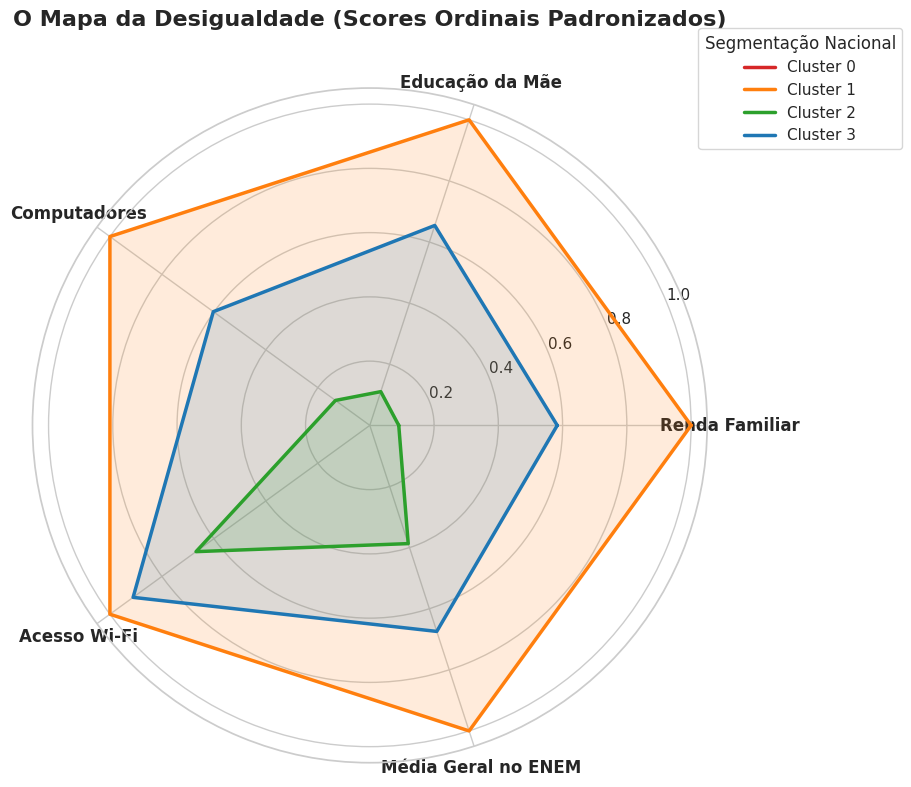


>>> PERFIL REAL MÉDIO DOS CLUSTERS (O que o Ministério deve olhar) <<<


,CLUSTER_FINAL,Q007_num,Q002_num,Q021_num,Q020_num,MEDIA_GERAL,TOTAL_CIDADES
0,0,0.06,0.50,0.07,0.42,481.28,122
1,1,0.56,0.81,0.57,0.96,565.42,403
2,2,0.11,0.54,0.14,0.79,513.83,713
3,3,0.35,0.71,0.37,0.92,538.02,515


In [49]:
# ==========================================
# BLOCO 10: COMPETIÇÃO DE CLUSTERING (K-MEANS VS K-MEDOIDS)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time

print("Iniciando o Pipeline de Clustering (K-Means vs K-Medoids)...\n")

# 1. Unindo a tabela Ordinal com as Notas e Abstenção da Camada Silver
df_ml = pd.merge(df_cidades_agregado, df_master_cidades[['CO_MUNICIPIO_PROVA', 'MEDIA_GERAL', 'TAXA_ABSTENCAO']], on='CO_MUNICIPIO_PROVA', how='inner')

# 2. Seleção de Features (As mais impactantes para o perfil da cidade)
features_ml = [
    'Q007_num', # Renda Familiar
    'Q002_num', # Escolaridade da Mãe
    'Q021_num', # Posse de Computador
    'Q020_num', # Acesso a Wi-Fi
    'MEDIA_GERAL' # Desempenho
]

X = df_ml[features_ml].dropna().copy()
# Alinhando o dataset principal com o X sem nulos
df_ml = df_ml.loc[X.index].copy()

# 3. Treinamento Simultâneo e Competição
K_FINAL = 4 # Definido como o ideal para segmentar o Brasil

pipe_kmeans = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=K_FINAL, init="k-means++", n_init=10, random_state=42))
])

pipe_kmedoids = Pipeline([
    ("scaler", StandardScaler()),
    ("kmedoids", KMedoids(n_clusters=K_FINAL, init='k-medoids++', random_state=42))
])

# Medindo tempo e ajustando os modelos
t0 = time.time(); pipe_kmeans.fit(X); tempo_kmeans = time.time() - t0
t0 = time.time(); pipe_kmedoids.fit(X); tempo_kmedoids = time.time() - t0

# 4. Avaliação de Métricas (Matriz de Comparação)
X_scaled = pipe_kmeans.named_steps["scaler"].transform(X) # A escala é a mesma para ambos
labels_kmeans = pipe_kmeans.predict(X)
labels_kmedoids = pipe_kmedoids.predict(X)

df_comparacao = pd.DataFrame({
    'Modelo': ['K-Means', 'K-Medoids'],
    'Silhouette Score (Maior = Melhor)': [silhouette_score(X_scaled, labels_kmeans), silhouette_score(X_scaled, labels_kmedoids)],
    'Davies-Bouldin (Menor = Melhor)': [davies_bouldin_score(X_scaled, labels_kmeans), davies_bouldin_score(X_scaled, labels_kmedoids)],
    'Tempo (Segundos)': [tempo_kmeans, tempo_kmedoids]
}).round(3)

print(">>> RESULTADO DA COMPETIÇÃO DOS MODELOS <<<")
display(df_comparacao)

# 5. Adotando o modelo vencedor (Geralmente K-Means) para a análise de Negócio
# Se o K-Medoids tiver métricas melhores no seu teste, você pode trocar aqui
df_ml['CLUSTER_FINAL'] = labels_kmeans

# ==========================================
# 6. DATA VIZ: O RADAR DAS POLÍTICAS PÚBLICAS
# ==========================================
# Calculando a média real de cada variável por Cluster
perfil_real = df_ml.groupby('CLUSTER_FINAL')[features_ml].mean().reset_index()

# Para o gráfico polar, normalizamos tudo de 0 a 1 (para colocar Nota 600 e Renda 10 na mesma escala visual)
scaler_radar = MinMaxScaler()
perfil_radar = perfil_real.copy()
perfil_radar[features_ml] = scaler_radar.fit_transform(perfil_real[features_ml])

# Ajuste visual do Gráfico de Radar
labels_radar = ['Renda Familiar', 'Educação da Mãe', 'Computadores', 'Acesso Wi-Fi', 'Média Geral no ENEM']
angulos = np.linspace(0, 2 * np.pi, len(labels_radar), endpoint=False).tolist()
angulos += angulos[:1]

plt.figure(figsize=(10, 8))
ax = plt.subplot(111, polar=True)

cores = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'] # Vermelho (Alerta) ao Azul (Elite)
nomes = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for i, row in perfil_radar.iterrows():
    valores = row[features_ml].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, linewidth=2.5, label=f"Cluster {i}", color=cores[i])
    ax.fill(angulos, valores, alpha=0.15, color=cores[i])

ax.set_thetagrids(np.degrees(angulos[:-1]), labels_radar, fontsize=12, fontweight='bold')
plt.title("O Mapa da Desigualdade (Scores Ordinais Padronizados)", fontsize=16, fontweight="bold", y=1.08)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), title="Segmentação Nacional")
plt.tight_layout()
plt.show()

# 7. Tabela Executiva para o Relatório
print("\n>>> PERFIL REAL MÉDIO DOS CLUSTERS (O que o Ministério deve olhar) <<<")
perfil_real['TOTAL_CIDADES'] = df_ml['CLUSTER_FINAL'].value_counts().sort_index()
display(perfil_real.round(2))

ZOOM NO PROBLEMA: Analisando isoladamente o Cluster mais vulnerável



/tmp/ipykernel_2150/1199343266.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cidades_por_estado.values, y=cidades_por_estado.index, palette="Reds_r")


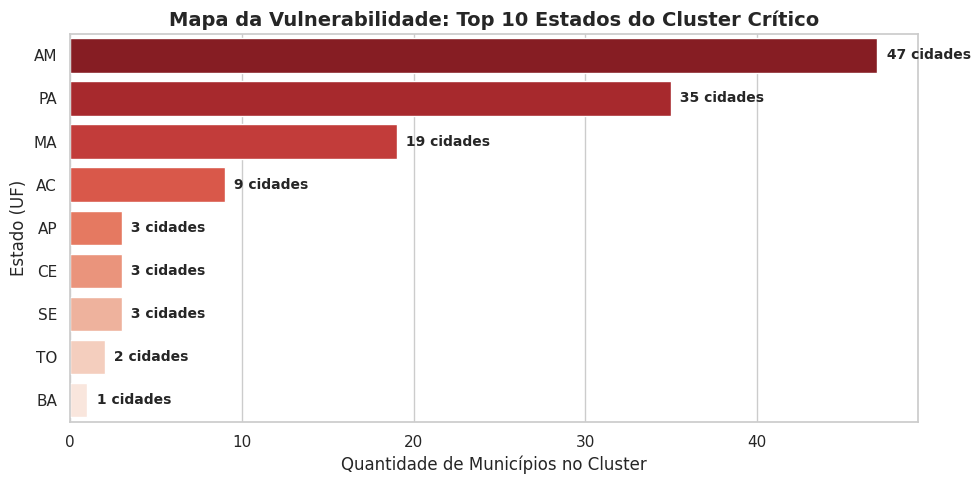


>>> OS DESVIOS POSITIVOS (Cidades que superaram a barreira da exclusão) <<<
Apesar do baixo poder aquisitivo no cluster, estes municípios alcançaram as maiores notas do grupo:


,NO_MUNICIPIO_PROVA,SG_UF_PROVA,Q007_num,Q021_num,MEDIA_GERAL
418,Mulungu,CE,0.061039,0.051446,530.779838
406,Madalena,CE,0.001490,0.041158,519.885684
450,Tejuçuoca,CE,0.031007,0.004125,516.616772
26,Cruzeiro do Sul,AC,0.171730,0.189926,511.284545
707,Boquira,BA,0.021234,0.045004,508.725347


In [50]:
# ==========================================
# BLOCO EXTRA: ANÁLISE INTRA-CLUSTER (Deep Dive no Cluster Crítico) - VERSÃO DEFINITIVA
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("="*80)
print(f"ZOOM NO PROBLEMA: Analisando isoladamente o Cluster mais vulnerável")
print("="*80 + "\n")

# 1. Padronização: Identifica dinamicamente a coluna de cluster gerada
coluna_cluster = 'CLUSTER_FINAL' if 'CLUSTER_FINAL' in df_ml.columns else 'CLUSTER'

# 2. TRAVA DE SEGURANÇA 1: Trazendo os nomes geográficos caso estejam ausentes
if 'NO_MUNICIPIO_PROVA' not in df_ml.columns:
    df_ml = pd.merge(df_ml, df_master_cidades[['CO_MUNICIPIO_PROVA', 'NO_MUNICIPIO_PROVA']], on='CO_MUNICIPIO_PROVA', how='inner')

if 'SG_UF_PROVA' not in df_ml.columns:
    df_ml = pd.merge(df_ml, df_master_cidades[['CO_MUNICIPIO_PROVA', 'SG_UF_PROVA']], on='CO_MUNICIPIO_PROVA', how='inner')

# 3. TRAVA DE SEGURANÇA 2: Mapeando dinamicamente as colunas socioeconômicas existentes
# Se os nomes ordinais do colega não estiverem no df_ml, trazemos do df_cidades_agregado ou calculamos
renda_col = 'Q007_num' if 'Q007_num' in df_ml.columns else ('PERC_RENDA_BAIXA' if 'PERC_RENDA_BAIXA' in df_ml.columns else 'Q007')
pc_col = 'Q021_num' if 'Q021_num' in df_ml.columns else ('PERC_SEM_PC' if 'PERC_SEM_PC' in df_ml.columns else 'Q021')

# Caso as colunas calculadas pelo colega estejam no df_cidades_agregado mas não no df_ml atual:
if renda_col not in df_ml.columns or pc_col not in df_ml.columns:
    print("⚠️ Colunas ordinais não encontradas no df_ml atual. Sincronizando com a tabela de mapeamento...")
    colunas_para_trazer = ['CO_MUNICIPIO_PROVA']
    if 'Q007_num' in df_cidades_agregado.columns and 'Q007_num' not in df_ml.columns: colunas_para_trazer.append('Q007_num')
    if 'Q021_num' in df_cidades_agregado.columns and 'Q021_num' not in df_ml.columns: colunas_para_trazer.append('Q021_num')

    if len(colunas_para_trazer) > 1:
        df_ml = pd.merge(df_ml, df_cidades_agregado[colunas_para_trazer], on='CO_MUNICIPIO_PROVA', how='inner')

    # Redefine os ponteiros corretos após o merge forçado
    renda_col = 'Q007_num'
    pc_col = 'Q021_num'

# 4. Identificando o cluster mais vulnerável (menor score médio de renda ou maior taxa de pobreza)
perfil_clusters = df_ml.groupby(coluna_cluster)[[renda_col, 'MEDIA_GERAL', pc_col]].mean()

# Se usou a métrica do colega (Q007_num), o menor valor é o mais pobre (idxmin). Se usou PERC_RENDA_BAIXA, o maior valor é o mais pobre (idxmax)
if 'Q007_num' in renda_col:
    cluster_critico = perfil_clusters[renda_col].idxmin()
else:
    cluster_critico = perfil_clusters[renda_col].idxmax()

# Isolando apenas as cidades do Cluster Crítico
df_foco = df_ml[df_ml[coluna_cluster] == cluster_critico].copy()

# 5. Análise Geográfica: Onde estão essas cidades?
cidades_por_estado = df_foco['SG_UF_PROVA'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=cidades_por_estado.values, y=cidades_por_estado.index, palette="Reds_r")

for container in ax.containers:
    ax.bar_label(container, fmt=' %d cidades', padding=3, fontsize=10, fontweight='bold')

plt.title(f'Mapa da Vulnerabilidade: Top 10 Estados do Cluster Crítico', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Municípios no Cluster')
plt.ylabel('Estado (UF)')
plt.tight_layout()
plt.show()

# 6. Exibindo os desvios positivos do grupo
cidades_heroínas = df_foco.sort_values(by='MEDIA_GERAL', ascending=False).head(5)

print("\n>>> OS DESVIOS POSITIVOS (Cidades que superaram a barreira da exclusão) <<<")
print("Apesar do baixo poder aquisitivo no cluster, estes municípios alcançaram as maiores notas do grupo:")
display(cidades_heroínas[['NO_MUNICIPIO_PROVA', 'SG_UF_PROVA', renda_col, pc_col, 'MEDIA_GERAL']])